## Section 1: Introduction to Clustering

### 1.1 Supervised vs. Unsupervised Learning

Machine learning problems broadly fall into two paradigms:

| Paradigm | Input | Output | Goal |
|---|---|---|---|
| **Supervised** | $(X, y)$ pairs | Predictions $\hat{y}$ | Minimize loss $\mathcal{L}(y, \hat{y})$ |
| **Unsupervised** | $X$ only | Structure/representation | Discover latent patterns |

**Clustering** is a fundamental unsupervised learning task: given a set of $n$ data points $\{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$ in $\mathbb{R}^d$, partition them into $k$ groups (clusters) such that points within a cluster are more similar to each other than to points in other clusters.

### 1.2 Taxonomy of Clustering Methods

```
Clustering
├── Partitional
│   ├── K-Means          ← our focus
│   ├── K-Medoids (PAM)
│   └── Fuzzy C-Means
├── Hierarchical
│   ├── Agglomerative (bottom-up)
│   └── Divisive (top-down)
├── Density-based
│   ├── DBSCAN
│   └── HDBSCAN
├── Model-based
│   └── Gaussian Mixture Models (EM)
└── Spectral
    └── Normalized Cuts
```

**Partitional** methods assign each point to exactly one cluster (hard assignment). **Hierarchical** methods produce a dendrogram showing nested cluster structure. **Density-based** methods define clusters as dense regions separated by sparse regions — capable of discovering arbitrary shapes.

### 1.3 Real-World Applications of K-Means

- **Customer segmentation**: Group users by purchase behavior for targeted marketing
- **Image compression**: Replace each pixel's color with its cluster centroid (vector quantization)
- **Document clustering**: Group news articles by topic (using TF-IDF or embeddings)
- **Anomaly detection**: Points far from any centroid are anomalies
- **Preprocessing**: Use cluster labels as features; use centroids to reduce dataset size
- **Genomics**: Cluster gene expression profiles to discover co-regulated genes
- **Recommendation systems**: Group users with similar preferences (collaborative filtering)

### 1.4 Key Assumptions of K-Means

Before applying K-Means, understand what it *assumes* about your data:

1. **Isotropic, convex clusters**: Clusters are approximately spherical in the feature space
2. **Similar sizes**: Clusters of wildly different sizes confuse the algorithm
3. **Similar densities**: Sparse and dense clusters coexist poorly
4. **Known $k$**: The number of clusters must be specified in advance
5. **Euclidean distance is meaningful**: Not always true in high dimensions or for categorical data

---

In [ ]:
# Environment Setup & Synthetic Data Generation

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ─── Global Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#A8DADC']
CENTROID_COLOR = '#264653'
SEED = 42
rng = np.random.default_rng(SEED)

# ─── Synthetic Dataset Factory ────────────────────────────────────────────────
def make_blobs(n_samples=400, centers=None, std=0.6, seed=SEED):
    """Generate isotropic Gaussian blobs."""
    rng_local = np.random.default_rng(seed)
    if centers is None:
        centers = np.array([[0, 0], [4, 0], [2, 3.5]])
    k = len(centers)
    n_per = n_samples // k
    X, y = [], []
    for i, c in enumerate(centers):
        X.append(rng_local.normal(loc=c, scale=std, size=(n_per, 2)))
        y.append(np.full(n_per, i))
    return np.vstack(X), np.hstack(y)

def make_moons(n_samples=400, noise=0.1, seed=SEED):
    """Non-convex crescent dataset."""
    rng_local = np.random.default_rng(seed)
    n = n_samples // 2
    theta1 = np.linspace(0, np.pi, n)
    theta2 = np.linspace(0, np.pi, n)
    X1 = np.c_[np.cos(theta1), np.sin(theta1)]
    X2 = np.c_[1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5]
    X = np.vstack([X1, X2]) + rng_local.normal(0, noise, (n_samples, 2))
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X, y

def make_noisy_blobs(n_samples=400, seed=SEED):
    """Blobs with added uniform noise outliers."""
    rng_local = np.random.default_rng(seed)
    X, y = make_blobs(n_samples=n_samples, seed=seed)
    n_noise = n_samples // 10
    noise = rng_local.uniform(-3, 7, (n_noise, 2))
    X = np.vstack([X, noise])
    y = np.hstack([y, np.full(n_noise, -1)])
    return X, y

def make_high_dim(n_samples=500, n_features=50, k=5, seed=SEED):
    """Gaussian blobs in high-dimensional space."""
    rng_local = np.random.default_rng(seed)
    centers = rng_local.normal(0, 3, (k, n_features))
    X, y = [], []
    for i, c in enumerate(centers):
        X.append(rng_local.normal(loc=c, scale=1.0, size=(n_samples//k, n_features)))
        y.append(np.full(n_samples//k, i))
    return np.vstack(X), np.hstack(y)

# Generate all datasets upfront
X_blobs, y_blobs = make_blobs()
X_moons, y_moons = make_moons()
X_noisy, y_noisy = make_noisy_blobs()
X_hd, y_hd = make_high_dim()

print(f"Blobs:     {X_blobs.shape}  —  {len(np.unique(y_blobs))} true clusters")
print(f"Moons:     {X_moons.shape}  —  {len(np.unique(y_moons))} true clusters (non-convex)")
print(f"Noisy:     {X_noisy.shape}  —  3 blobs + 40 outliers")
print(f"High-dim:  {X_hd.shape}  —  {len(np.unique(y_hd))} clusters in 50D")

Blobs:     (399, 2)  —  3 true clusters
Moons:     (400, 2)  —  2 true clusters (non-convex)
Noisy:     (439, 2)  —  3 blobs + 40 outliers
High-dim:  (500, 50)  —  5 clusters in 50D


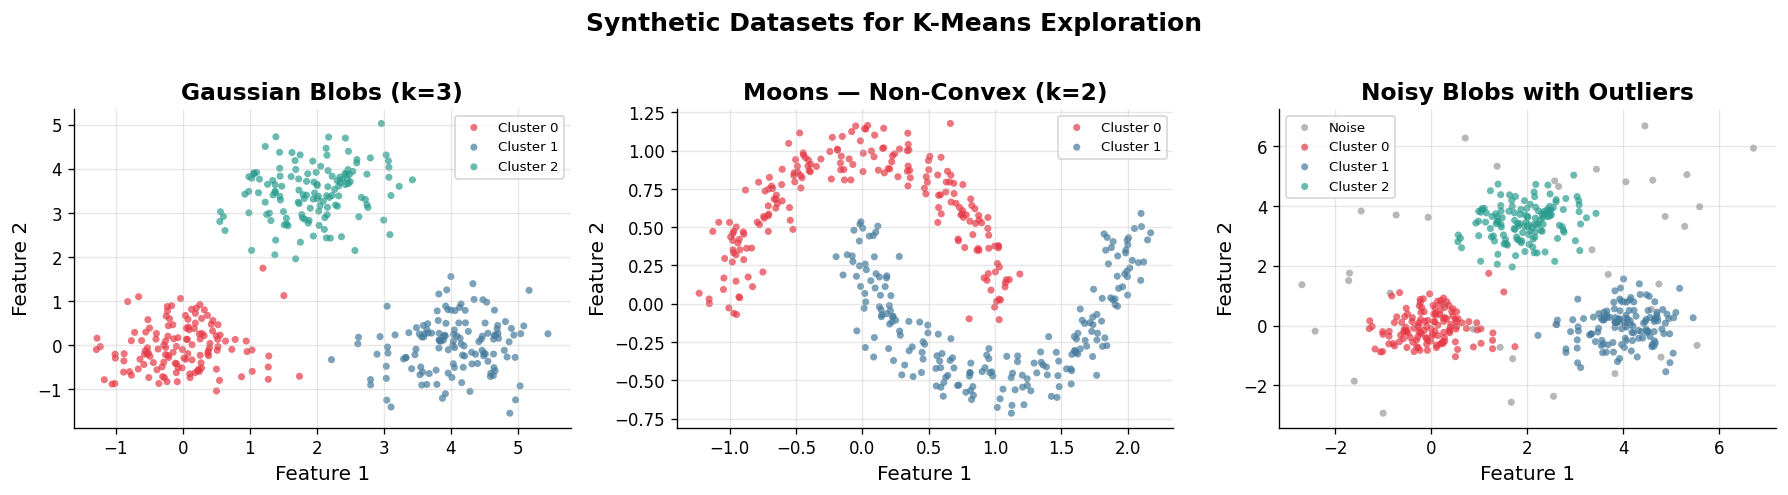

✓ Datasets visualized


In [ ]:
# Dataset Overview Plot

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (X_blobs, y_blobs, 'Gaussian Blobs (k=3)'),
    (X_moons, y_moons, 'Moons — Non-Convex (k=2)'),
    (X_noisy, y_noisy, 'Noisy Blobs with Outliers'),
]

for ax, (X, y, title) in zip(axes, datasets):
    unique_labels = np.unique(y)
    for i, lbl in enumerate(unique_labels):
        mask = y == lbl
        color = '#999999' if lbl == -1 else PALETTE[int(lbl) % len(PALETTE)]
        label = 'Noise' if lbl == -1 else f'Cluster {int(lbl)}'
        ax.scatter(X[mask, 0], X[mask, 1], c=color, s=18, alpha=0.7,
                   edgecolors='none', label=label)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Synthetic Datasets for K-Means Exploration', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('datasets_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Datasets visualized")

## Section 2: Mathematical Formulation

### 2.1 The Objective Function (WCSS)

K-Means seeks a partition $\mathcal{C} = \{C_1, C_2, \ldots, C_k\}$ of $n$ points into $k$ clusters that minimizes the **Within-Cluster Sum of Squares (WCSS)**:

$$
J(\mathcal{C}, \boldsymbol{\mu}) = \sum_{j=1}^{k} \sum_{\mathbf{x}_i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|_2^2
$$

where $\boldsymbol{\mu}_j = \frac{1}{|C_j|}\sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i$ is the **centroid** (mean) of cluster $j$.

This can be written compactly using indicator variables $r_{ij} \in \{0, 1\}$ where $r_{ij} = 1$ iff point $i$ belongs to cluster $j$:

$$
J = \sum_{i=1}^{n} \sum_{j=1}^{k} r_{ij} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|_2^2 \quad \text{subject to} \quad \sum_{j=1}^{k} r_{ij} = 1 \; \forall i
$$

### 2.2 Why the Mean Minimizes Within-Cluster Variance

**Theorem**: For a fixed cluster assignment, the centroid $\boldsymbol{\mu}_j^*$ that minimizes $J$ is the arithmetic mean.

**Proof**: Fix cluster $C_j$. We want to minimize

$$
f(\boldsymbol{\mu}_j) = \sum_{\mathbf{x}_i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2
$$

Taking the gradient and setting to zero:

$$
\nabla_{\boldsymbol{\mu}_j} f = -2 \sum_{\mathbf{x}_i \in C_j} (\mathbf{x}_i - \boldsymbol{\mu}_j) = \mathbf{0}
$$

$$
\sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i = |C_j| \cdot \boldsymbol{\mu}_j
$$

$$
\therefore \quad \boldsymbol{\mu}_j^* = \frac{1}{|C_j|} \sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i \quad \square
$$

The Hessian is $2|C_j|\mathbf{I} \succ 0$, confirming this is a **global minimum** for fixed assignments. The centroid is the unique minimizer of squared Euclidean distance — this wouldn't hold for Manhattan distance (which gives the coordinate-wise median) or other metrics.

### 2.3 The Combinatorial Hardness

The joint optimization over both assignments $r_{ij}$ and centroids $\boldsymbol{\mu}_j$ is **NP-hard** in general (even for $k=2$ in high dimensions). The number of possible partitions of $n$ points into $k$ non-empty subsets is given by the **Stirling number of the second kind** $S(n, k)$, which grows super-exponentially.

For $n=100$, $k=5$: there are $\approx 10^{68}$ possible partitions.

Lloyd's algorithm finds a **local optimum** efficiently, but cannot guarantee the global optimum.

### 2.4 Geometric Interpretation: Voronoi Diagrams

The assignment step of K-Means partitions the space into **Voronoi regions**. The Voronoi region of centroid $\boldsymbol{\mu}_j$ is:

$$
V_j = \{\mathbf{x} \in \mathbb{R}^d : \|\mathbf{x} - \boldsymbol{\mu}_j\| \leq \|\mathbf{x} - \boldsymbol{\mu}_\ell\| \;\; \forall \ell \neq j\}
$$

Each Voronoi region is a **convex polytope** — this is why K-Means can only find convex clusters. The decision boundary between two clusters $j$ and $\ell$ is the perpendicular bisecting hyperplane of the segment $[\boldsymbol{\mu}_j, \boldsymbol{\mu}_\ell]$.

### 2.5 Convexity Discussion

**Is the K-Means objective convex?**  
- In $\boldsymbol{\mu}_j$ alone (fixed assignments): **Yes** — sum of squared norms is convex ✓  
- In $r_{ij}$ alone (fixed centroids): **Yes** — linear in $r_{ij}$ (with integer constraint relaxed) ✓  
- **Jointly** in $(\boldsymbol{\mu}, r)$: **No** — the problem is non-convex due to the product $r_{ij}\boldsymbol{\mu}_j$ and integer constraints ✗

This non-convexity is the fundamental reason K-Means is sensitive to initialization.

---

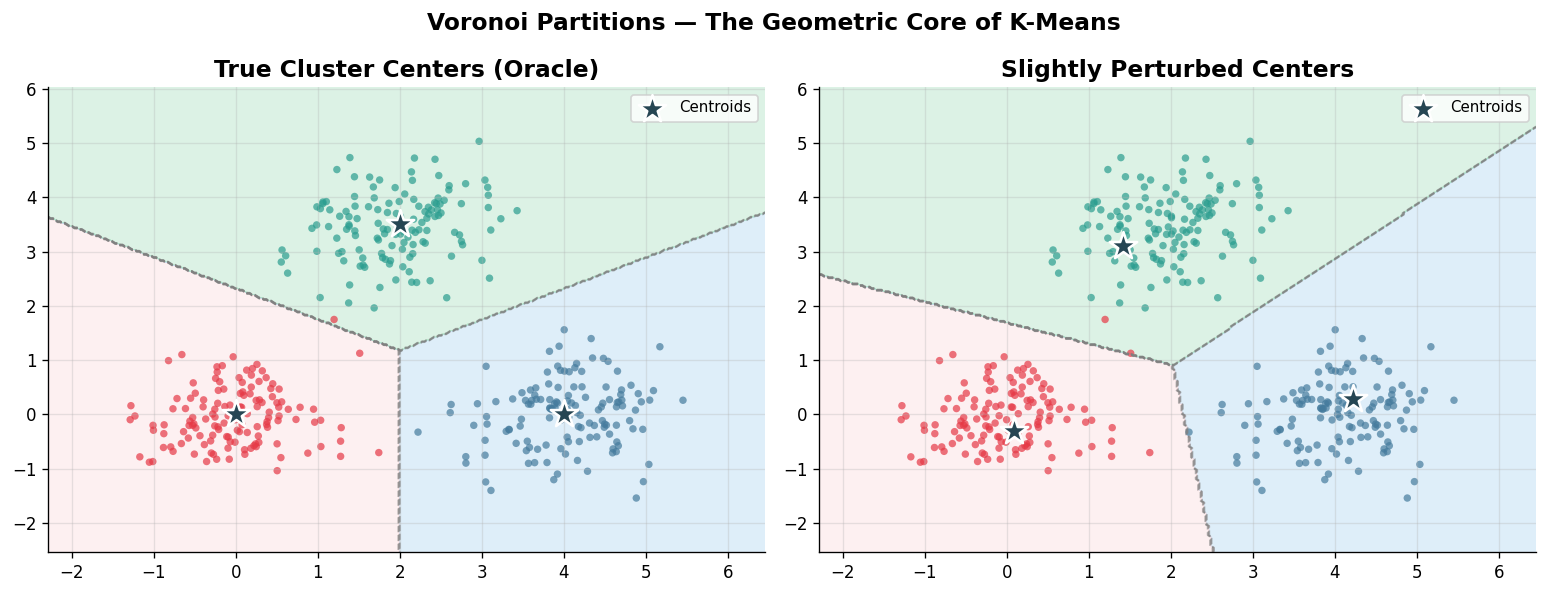

✓ Voronoi diagrams shown
Note: Decision boundaries are perpendicular bisectors between centroids


In [ ]:
# Voronoi Diagram Visualization

from matplotlib.colors import ListedColormap

def plot_voronoi(centers, X, y, ax, title='Voronoi Partition'):
    """Visualize the Voronoi regions defined by centroids."""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Assign each grid point to nearest centroid
    dists = np.linalg.norm(grid[:, None, :] - centers[None, :, :], axis=2)
    zz = np.argmin(dists, axis=1).reshape(xx.shape)
    
    cmap_bg = ListedColormap([c + 'aa' for c in  # light version
                              ['#FADADD', '#AED6F1', '#A9DFBF', '#FAD7A0', '#D2B4DE', '#AED6F1']][:len(centers)])
    ax.contourf(xx, yy, zz, alpha=0.4, cmap=cmap_bg)
    ax.contour(xx, yy, zz, colors='gray', linewidths=1, linestyles='--', alpha=0.5)
    
    unique_labels = np.unique(y)
    for i, lbl in enumerate(unique_labels):
        mask = y == lbl
        ax.scatter(X[mask, 0], X[mask, 1], c=PALETTE[int(lbl) % len(PALETTE)],
                   s=20, alpha=0.7, edgecolors='none')
    ax.scatter(centers[:, 0], centers[:, 1], marker='*', s=300,
               c=CENTROID_COLOR, edgecolors='white', linewidths=1.5,
               zorder=10, label='Centroids')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

# Use true centers + slight noise to simulate K-Means centroids
true_centers = np.array([[0., 0.], [4., 0.], [2., 3.5]])
noisy_centers = true_centers + rng.normal(0, 0.3, true_centers.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_voronoi(true_centers, X_blobs, y_blobs, axes[0], 'True Cluster Centers (Oracle)')
plot_voronoi(noisy_centers, X_blobs, y_blobs, axes[1], 'Slightly Perturbed Centers')

plt.suptitle('Voronoi Partitions — The Geometric Core of K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('voronoi.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Voronoi diagrams shown")
print("Note: Decision boundaries are perpendicular bisectors between centroids")

## Section 3: Lloyd's Algorithm — Deep Derivation

### 3.1 The Algorithm

Lloyd's algorithm (1957, published 1982) alternates between two steps:

**Step 1 — Assignment (E-step analog)**: Assign each point to the nearest centroid:

$$
r_{ij}^{(t+1)} = \begin{cases} 1 & \text{if } j = \arg\min_\ell \|\mathbf{x}_i - \boldsymbol{\mu}_\ell^{(t)}\|^2 \\ 0 & \text{otherwise} \end{cases}
$$

**Step 2 — Update (M-step analog)**: Recompute centroids as cluster means:

$$
\boldsymbol{\mu}_j^{(t+1)} = \frac{\sum_{i=1}^{n} r_{ij}^{(t+1)} \mathbf{x}_i}{\sum_{i=1}^{n} r_{ij}^{(t+1)}}
$$

### 3.2 Why This Works: Block Coordinate Descent

Lloyd's algorithm is an instance of **alternating minimization** (also called block coordinate descent):

- Hold $\boldsymbol{\mu}$ fixed → minimize $J$ over $r$ → **Assignment step** (exactly solves the subproblem: nearest centroid)
- Hold $r$ fixed → minimize $J$ over $\boldsymbol{\mu}$ → **Update step** (exactly solves the subproblem: mean)

Each step **does not increase** $J$:

$$
J(r^{(t+1)}, \boldsymbol{\mu}^{(t)}) \leq J(r^{(t)}, \boldsymbol{\mu}^{(t)}) \quad \text{(Assignment)}
$$

$$
J(r^{(t+1)}, \boldsymbol{\mu}^{(t+1)}) \leq J(r^{(t+1)}, \boldsymbol{\mu}^{(t)}) \quad \text{(Update)}
$$

Therefore: $J^{(t+1)} \leq J^{(t)}$ — the objective is **monotonically non-increasing**.

### 3.3 Convergence Guarantee

Since:
1. $J$ is bounded below by 0
2. $J$ decreases at each step
3. The number of distinct partitions is finite ($S(n, k)$)

Lloyd's algorithm **must converge** in a finite number of iterations. However, it converges to a **local minimum** (or saddle point), not necessarily the global minimum.

**Typical stopping criteria**:
- Centroids move less than tolerance $\epsilon$: $\max_j \|\boldsymbol{\mu}_j^{(t+1)} - \boldsymbol{\mu}_j^{(t)}\| < \epsilon$
- No reassignments occur
- Maximum iterations $T_{\max}$ reached

### 3.4 Complexity Analysis

Each iteration costs:
- **Assignment**: For each of $n$ points, compute distance to each of $k$ centroids in $\mathbb{R}^d$: $O(nkd)$
- **Update**: For each of $k$ clusters, sum $n_j$ points in $\mathbb{R}^d$: $O(nd)$

**Total per iteration**: $O(nkd)$ (assignment dominates for $k > 1$)

**Over $T$ iterations**: $O(nkdT)$

In practice, $T$ is typically 10–100 iterations. K-Means is thus **linear** in $n$, making it scalable to millions of points. Compare to hierarchical clustering at $O(n^2 \log n)$ or $O(n^3)$.

### 3.5 Ties and Edge Cases

- **Equidistant points**: If a point is equidistant to two centroids, a consistent tie-breaking rule (e.g., lower index) must be used
- **Empty clusters**: If a cluster becomes empty (all its points are reassigned), the algorithm must either remove it (reducing $k$) or reinitialize the centroid (e.g., to the point with maximum reconstruction error)
- **Degenerate initializations**: If two centroids coincide, one cluster will be empty immediately

---

In [ ]:
# Core KMeans Implementation From Scratch

class KMeansScratch:
    """
    K-Means clustering implemented entirely from scratch using NumPy.
    
    Implements:
      - Random initialization
      - K-Means++ initialization  
      - Lloyd's algorithm
      - Multiple restarts
      - Full convergence tracking
    
    Parameters
    ----------
    k : int
        Number of clusters.
    init : str
        Initialization strategy: 'random' or 'kmeans++'.
    max_iter : int
        Maximum number of Lloyd iterations.
    tol : float
        Convergence tolerance on centroid movement.
    n_init : int
        Number of independent restarts; best result is kept.
    seed : int
        Random seed for reproducibility.
    """
    
    def __init__(self, k=3, init='kmeans++', max_iter=300, tol=1e-4, n_init=10, seed=42):
        self.k = k
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.n_init = n_init
        self.seed = seed
        
        # Results populated after fit()
        self.centroids_ = None        # shape (k, d)
        self.labels_ = None           # shape (n,)
        self.inertia_ = None          # final WCSS
        self.n_iter_ = None           # iterations until convergence
        self.loss_history_ = None     # WCSS per iteration (best run)
        self.centroid_history_ = None # centroid positions per iteration (best run)
    
    # ─── Initialization ────────────────────────────────────────────────────
    
    def initialize_centroids(self, X, rng):
        """Initialize centroids using specified strategy."""
        if self.init == 'random':
            return self._init_random(X, rng)
        elif self.init == 'kmeans++':
            return self._init_kmeans_plus_plus(X, rng)
        else:
            raise ValueError(f"Unknown init: {self.init!r}. Use 'random' or 'kmeans++'")
    
    def _init_random(self, X, rng):
        """Uniform random selection of k data points as initial centroids."""
        indices = rng.choice(len(X), size=self.k, replace=False)
        return X[indices].copy()
    
    def _init_kmeans_plus_plus(self, X, rng):
        """
        K-Means++ initialization (Arthur & Vassilvitskii, 2007).
        
        Each successive centroid is chosen with probability proportional
        to D(x)^2 — the squared distance to the nearest existing centroid.
        
        Guarantees: E[J] ≤ 8(ln k + 2) * J_OPT
        """
        n, d = X.shape
        centroids = []
        
        # Step 1: Choose first centroid uniformly at random
        idx = rng.integers(0, n)
        centroids.append(X[idx].copy())
        
        for _ in range(1, self.k):
            # Step 2: Compute D(x)^2 = min squared distance to existing centroids
            C = np.array(centroids)              # (c, d) where c = number placed so far
            diffs = X[:, np.newaxis, :] - C      # (n, c, d)
            sq_dists = (diffs ** 2).sum(axis=2)  # (n, c)
            D2 = sq_dists.min(axis=1)            # (n,)
            
            # Step 3: Sample next centroid with probability ∝ D(x)^2
            probs = D2 / D2.sum()
            idx = rng.choice(n, p=probs)
            centroids.append(X[idx].copy())
        
        return np.array(centroids)  # (k, d)
    
    # ─── Core Steps ────────────────────────────────────────────────────────
    
    def assign_clusters(self, X, centroids):
        """
        Assign each point to the nearest centroid.
        
        Vectorized via broadcasting: avoids Python loops.
        
        Parameters
        ----------
        X : ndarray, shape (n, d)
        centroids : ndarray, shape (k, d)
        
        Returns
        -------
        labels : ndarray, shape (n,), dtype int
        """
        # X[:, np.newaxis, :] → (n, 1, d)
        # centroids[np.newaxis, :, :] → (1, k, d)
        # diff → (n, k, d)
        diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]  # (n, k, d)
        sq_dists = (diff ** 2).sum(axis=2)                         # (n, k)
        return np.argmin(sq_dists, axis=1)                         # (n,)
    
    def update_centroids(self, X, labels):
        """
        Recompute centroids as the mean of assigned points.
        
        Handles empty clusters by reinitializing to a random data point.
        
        Parameters
        ----------
        X : ndarray, shape (n, d)
        labels : ndarray, shape (n,)
        
        Returns
        -------
        centroids : ndarray, shape (k, d)
        """
        n, d = X.shape
        centroids = np.zeros((self.k, d))
        for j in range(self.k):
            mask = labels == j
            if mask.sum() == 0:
                # Empty cluster: reinitialize to a random data point
                centroids[j] = X[np.random.randint(n)]
            else:
                centroids[j] = X[mask].mean(axis=0)
        return centroids
    
    def compute_loss(self, X, labels, centroids):
        """
        Compute WCSS: J = Σ_j Σ_{x in C_j} ||x - μ_j||²
        
        Parameters
        ----------
        X : ndarray, shape (n, d)
        labels : ndarray, shape (n,)
        centroids : ndarray, shape (k, d)
        
        Returns
        -------
        loss : float
        """
        # Gather assigned centroid for each point
        assigned = centroids[labels]          # (n, d)
        sq_dists = ((X - assigned) ** 2).sum(axis=1)  # (n,)
        return sq_dists.sum()
    
    # ─── Main Fit Loop ─────────────────────────────────────────────────────
    
    def _fit_once(self, X, rng):
        """Run one complete Lloyd's algorithm from one initialization."""
        centroids = self.initialize_centroids(X, rng)
        loss_history = []
        centroid_history = [centroids.copy()]
        
        for t in range(self.max_iter):
            # E-step: assignment
            labels = self.assign_clusters(X, centroids)
            loss = self.compute_loss(X, labels, centroids)
            loss_history.append(loss)
            
            # M-step: update
            new_centroids = self.update_centroids(X, labels)
            centroid_history.append(new_centroids.copy())
            
            # Convergence check: max centroid movement
            shift = np.linalg.norm(new_centroids - centroids, axis=1).max()
            centroids = new_centroids
            
            if shift < self.tol:
                break
        
        # Final assignment
        labels = self.assign_clusters(X, centroids)
        loss = self.compute_loss(X, labels, centroids)
        
        return centroids, labels, loss, loss_history, centroid_history, t + 1
    
    def fit(self, X):
        """
        Fit K-Means to data X.
        
        Runs n_init independent restarts and keeps the best result
        (lowest inertia = WCSS). This is essential to escape local minima.
        
        Parameters
        ----------
        X : ndarray, shape (n, d)
        
        Returns
        -------
        self
        """
        rng = np.random.default_rng(self.seed)
        
        best_loss = np.inf
        best_result = None
        
        for run in range(self.n_init):
            result = self._fit_once(X, rng)
            centroids, labels, loss, loss_history, centroid_history, n_iter = result
            
            if loss < best_loss:
                best_loss = loss
                best_result = result
        
        (self.centroids_, self.labels_, self.inertia_,
         self.loss_history_, self.centroid_history_, self.n_iter_) = best_result
        
        return self
    
    def predict(self, X):
        """
        Assign new points to the nearest centroid.
        Requires fit() to have been called.
        
        Parameters
        ----------
        X : ndarray, shape (m, d)
        
        Returns
        -------
        labels : ndarray, shape (m,)
        """
        if self.centroids_ is None:
            raise RuntimeError("Call fit() before predict()")
        return self.assign_clusters(X, self.centroids_)
    
    def fit_predict(self, X):
        """Fit and return cluster labels."""
        return self.fit(X).labels_
    
    def __repr__(self):
        return (f"KMeansScratch(k={self.k}, init={self.init!r}, "
                f"max_iter={self.max_iter}, n_init={self.n_init})")


# Quick sanity check
km = KMeansScratch(k=3, init='kmeans++', n_init=10, seed=SEED)
km.fit(X_blobs)
print(repr(km))
print(f"Inertia (WCSS): {km.inertia_:.2f}")
print(f"Converged in:   {km.n_iter_} iterations")
print(f"Cluster sizes:  {np.bincount(km.labels_)}")
print(f"Centroids:\n{km.centroids_.round(3)}")

KMeansScratch(k=3, init='kmeans++', max_iter=300, n_init=10)
Inertia (WCSS): 276.36
Converged in:   3 iterations
Cluster sizes:  [132 133 134]
Centroids:
[[-0.027 -0.048]
 [ 4.031  0.007]
 [ 1.94   3.447]]


## Section 5: Visualization of Convergence

Watching K-Means converge is one of the most instructive experiences in ML.

We will:
1. Track centroid positions at each iteration
2. Show the assignment boundaries evolving over time  
3. Plot the loss curve to confirm monotonic decrease
4. Overlay centroid trajectories to show movement paths

The centroid trajectories reveal the optimization landscape: centroids "fall" toward the center of mass of their assigned points, which in turn changes as centroids move — a coupled dynamical system.

---

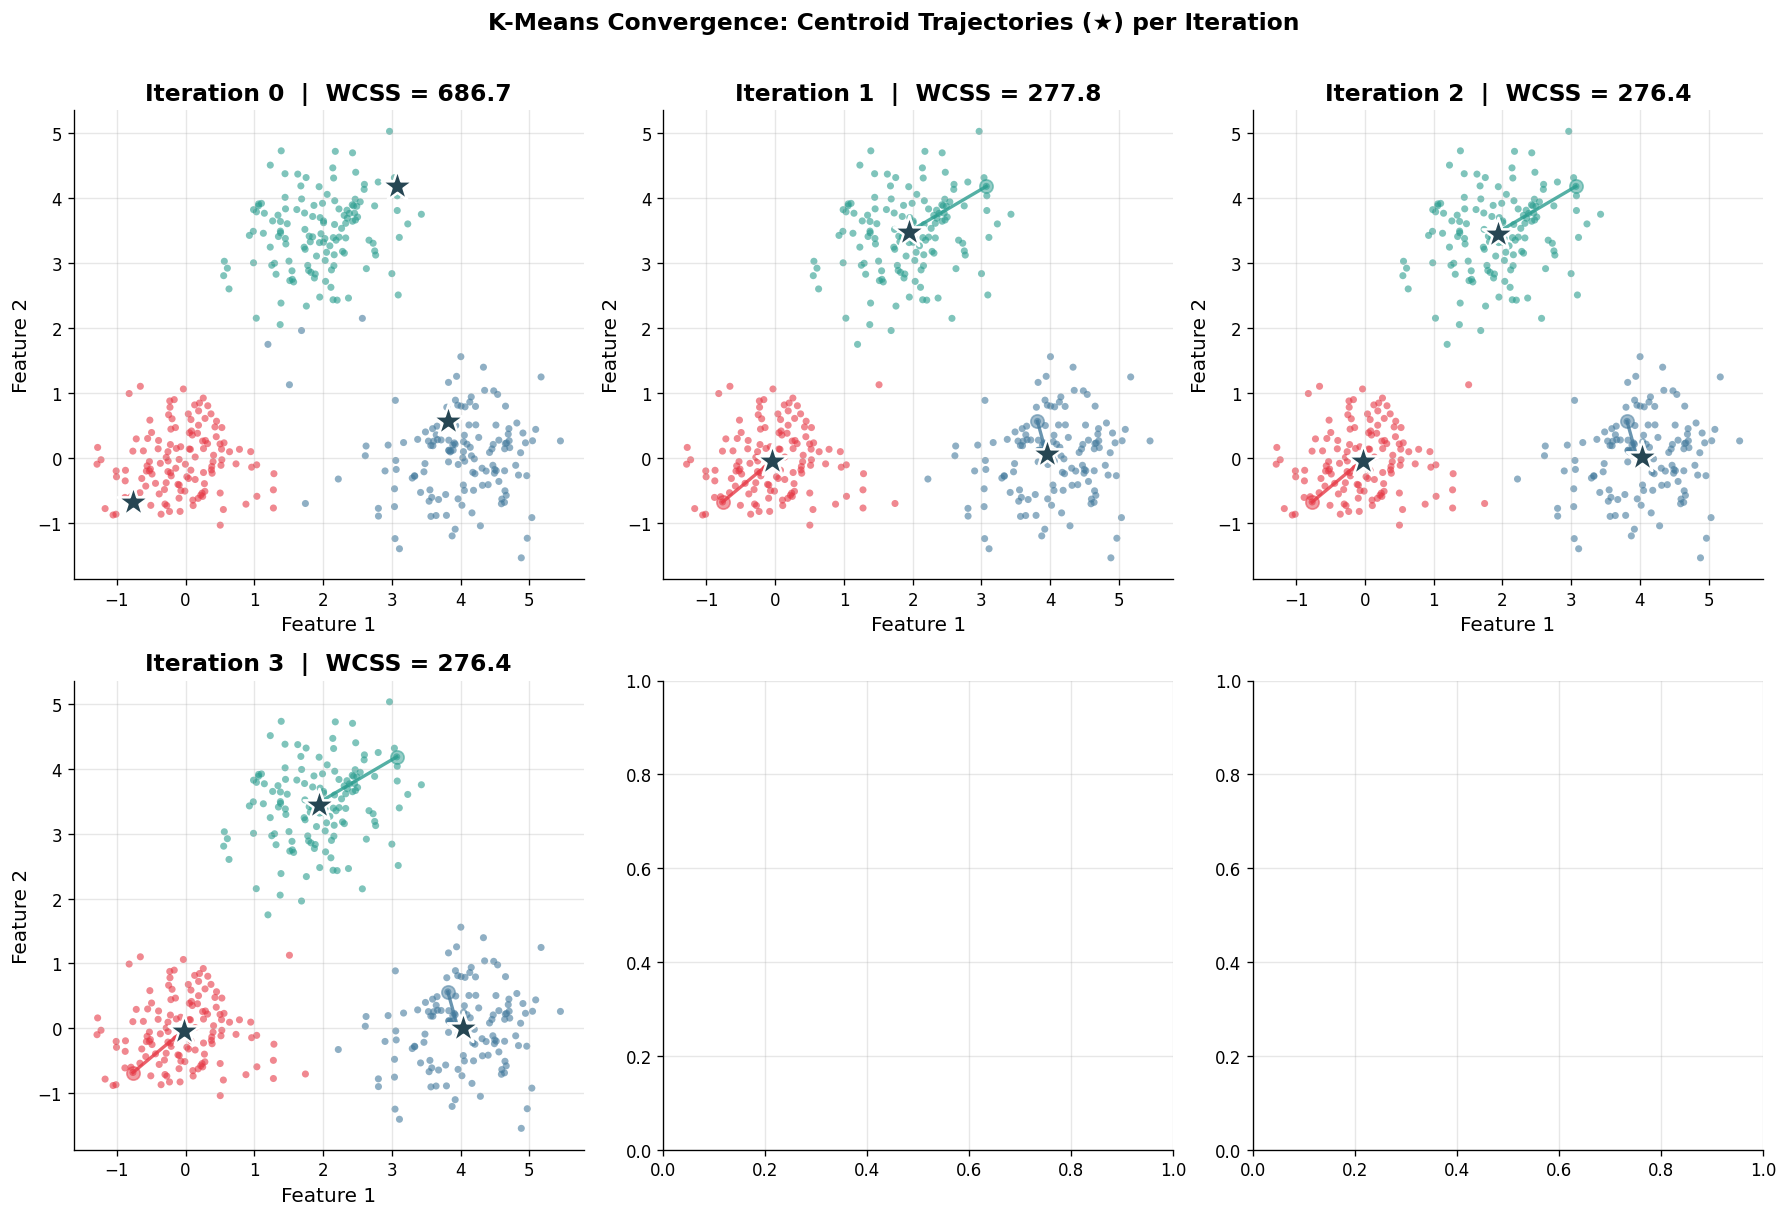

✓ Converged in 3 iterations


In [ ]:
# Convergence Visualization: Iteration-by-Iteration

# Run with tracking enabled (use single init to have the history)
km_tracked = KMeansScratch(k=3, init='kmeans++', max_iter=20, n_init=1, seed=SEED)
km_tracked.fit(X_blobs)

centroid_hist = np.array(km_tracked.centroid_history_)  # (iters, k, d)
loss_hist = km_tracked.loss_history_
n_snapshots = min(6, len(centroid_hist))
snap_iters = np.linspace(0, len(centroid_hist)-1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax_idx, t in enumerate(snap_iters):
    ax = axes[ax_idx]
    centroids_t = centroid_hist[t]  # (k, d)
    
    # Compute assignments for this snapshot
    diff = X_blobs[:, np.newaxis, :] - centroids_t[np.newaxis, :, :]
    labels_t = np.argmin((diff**2).sum(axis=2), axis=1)
    
    # Plot points with current assignments
    for j in range(3):
        mask = labels_t == j
        ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                   c=PALETTE[j], s=18, alpha=0.6, edgecolors='none')
    
    # Plot centroids
    ax.scatter(centroids_t[:, 0], centroids_t[:, 1],
               marker='*', s=400, c=CENTROID_COLOR,
               edgecolors='white', linewidths=1.5, zorder=10)
    
    # Draw centroid paths
    for j in range(3):
        path = centroid_hist[:t+1, j, :]  # trajectory up to time t
        ax.plot(path[:, 0], path[:, 1], '-', color=PALETTE[j],
                linewidth=2, alpha=0.8)
        ax.plot(centroid_hist[0, j, 0], centroid_hist[0, j, 1],
                'o', color=PALETTE[j], markersize=8, alpha=0.5, label='Init' if j==0 else '')
    
    wcss = sum((X_blobs - centroids_t[labels_t])**2 * 1.0) if t < len(loss_hist) else loss_hist[-1]
    try:
        wcss_val = loss_hist[t]
    except IndexError:
        wcss_val = loss_hist[-1]
    ax.set_title(f'Iteration {t}  |  WCSS = {wcss_val:.1f}', fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('K-Means Convergence: Centroid Trajectories (★) per Iteration',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('convergence_iters.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ Converged in {km_tracked.n_iter_} iterations")

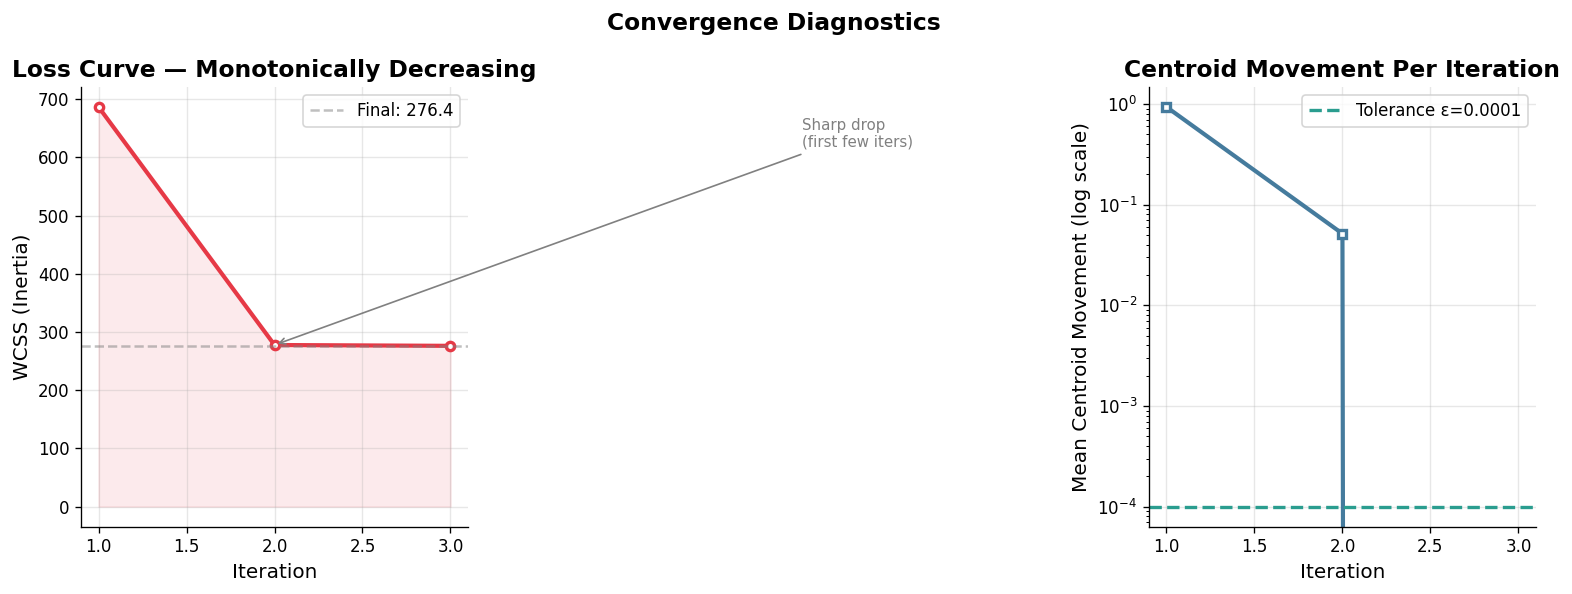

✓ Loss decreased from 686.7 to 276.4 (59.8% reduction)


In [ ]:
# Loss Curve & Centroid Movement

# Run a longer single run for smooth loss curve
km_loss = KMeansScratch(k=3, init='kmeans++', max_iter=50, n_init=1, seed=SEED)
km_loss.fit(X_blobs)

loss_hist = km_loss.loss_history_
centroid_hist = np.array(km_loss.centroid_history_)

# Centroid movement per iteration
movements = []
for t in range(1, len(centroid_hist)):
    mv = np.linalg.norm(centroid_hist[t] - centroid_hist[t-1], axis=1).mean()
    movements.append(mv)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ─── Loss curve ───────────────────────────────────────────────────────────────
iters = range(1, len(loss_hist) + 1)
ax1.plot(iters, loss_hist, 'o-', color='#E63946', linewidth=2.5,
         markersize=5, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(iters, loss_hist, alpha=0.1, color='#E63946')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('WCSS (Inertia)')
ax1.set_title('Loss Curve — Monotonically Decreasing', fontweight='bold')
ax1.axhline(y=loss_hist[-1], color='gray', linestyle='--', alpha=0.5, label=f'Final: {loss_hist[-1]:.1f}')
ax1.legend()

# Annotate convergence
ax1.annotate('Sharp drop\n(first few iters)',
             xy=(2, loss_hist[1]), xytext=(5, loss_hist[0]*0.9),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color='gray')

# ─── Centroid movement ────────────────────────────────────────────────────────
mv_iters = range(1, len(movements) + 1)
ax2.semilogy(mv_iters, movements, 's-', color='#457B9D', linewidth=2.5,
              markersize=5, markerfacecolor='white', markeredgewidth=2)
ax2.axhline(y=km_loss.tol, color='#2A9D8F', linestyle='--',
            linewidth=2, label=f'Tolerance ε={km_loss.tol}')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Mean Centroid Movement (log scale)')
ax2.set_title('Centroid Movement Per Iteration', fontweight='bold')
ax2.legend()

plt.suptitle('Convergence Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ Loss decreased from {loss_hist[0]:.1f} to {loss_hist[-1]:.1f} ({(1-loss_hist[-1]/loss_hist[0])*100:.1f}% reduction)")

## Section 6: Initialization Strategies

### 6.1 Why Initialization Matters

The K-Means objective is **non-convex**. Lloyd's algorithm is guaranteed to converge to a **local minimum**, but the quality of that local minimum depends critically on where the centroids start.

Poor initialization can lead to:
- Multiple centroids collapsing onto the same cluster
- Empty clusters early in training
- Convergence to a high-inertia local minimum
- Many more iterations needed to converge

### 6.2 Random Initialization

**Approach**: Sample $k$ data points uniformly at random (without replacement) as initial centroids.

**Problems**:
- Centroids may be placed in the same true cluster
- Results are highly variable — different seeds give very different outcomes
- Expected inertia can be $\Omega(\log k)$ times optimal

**Mitigation**: Run $n\_init$ times with different seeds and keep the best result.

### 6.3 K-Means++ (Arthur & Vassilvitskii, 2007)

**Key Idea**: Choose initial centroids that are spread out across the data by sampling proportionally to the squared distance from existing centroids.

**Algorithm**:
1. Choose first centroid $\boldsymbol{\mu}_1$ uniformly at random from $X$
2. For $c = 2, 3, \ldots, k$:
   - Compute $D(\mathbf{x})^2 = \min_{j < c} \|\mathbf{x} - \boldsymbol{\mu}_j\|^2$ for each point
   - Sample next centroid with probability $P(\mathbf{x}) \propto D(\mathbf{x})^2$
3. Run Lloyd's algorithm

**Theoretical Guarantee** (Arthur & Vassilvitskii, 2007):

$$
\mathbb{E}[J_{\text{K-Means++}}] \leq 8(\ln k + 2) \cdot J_{\text{OPT}}
$$

This is an $O(\log k)$-approximation guarantee — dramatically better than random initialization.

**Intuition**: By preferring points far from existing centroids, K-Means++ ensures the initial centroids cover the data space well. It's a probabilistic greedy algorithm.

**Cost**: $O(knd)$ additional computation for initialization — negligible compared to the full algorithm.

### 6.4 Other Initialization Strategies

- **Forgy**: Same as random selection of $k$ distinct points
- **Random Partition**: Assign each point to a random cluster, then compute centroids. More robust to outliers than Forgy
- **PCA-based**: Place centroids along the first principal component — effective for linearly separable clusters
- **Bradley & Fayyad (1998)**: Run K-Means on subsamples, cluster the resulting centroids, use those as initialization
- **Spherical K-Means++**: Adaptation for directional/high-dimensional data

---

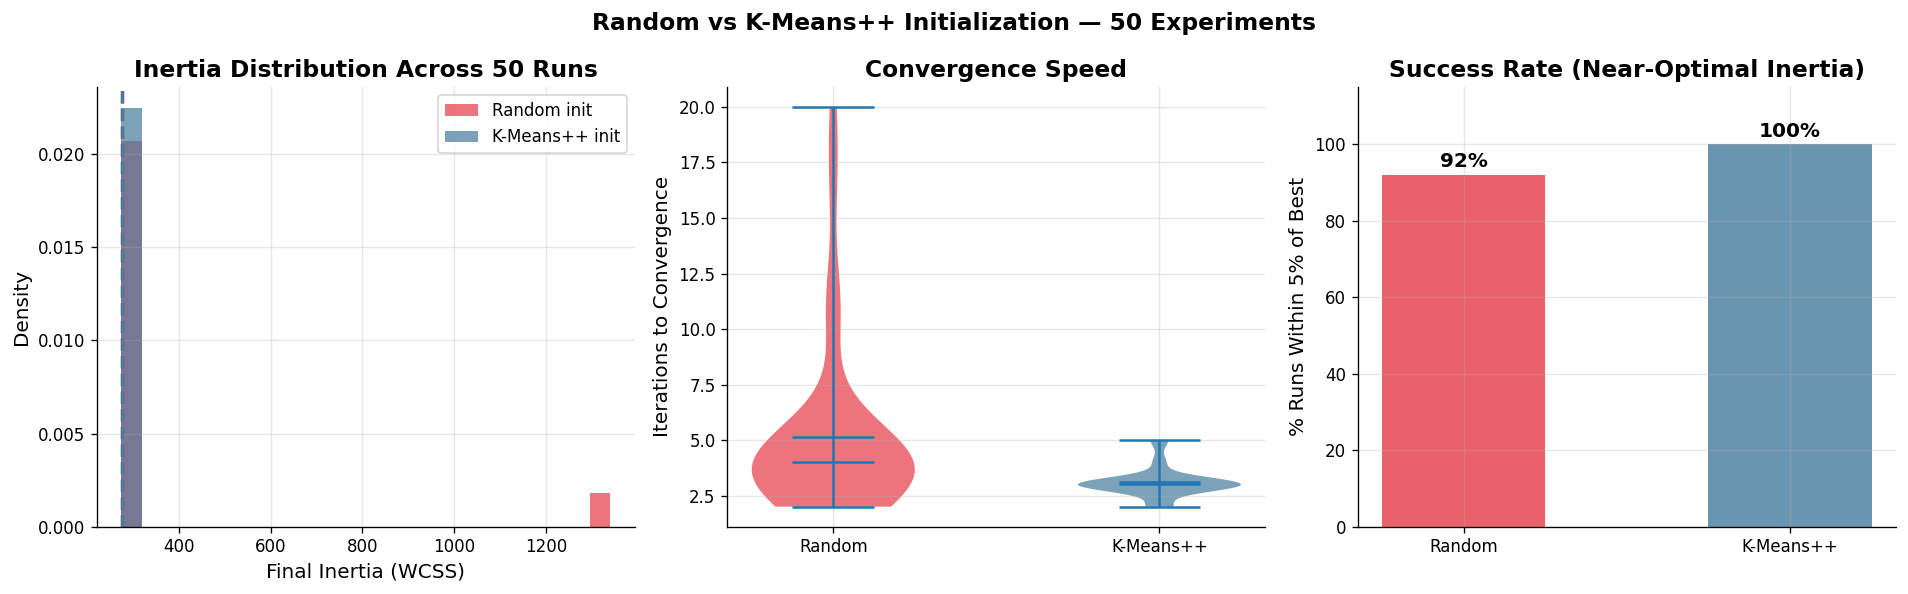

Summary:
  Random  — Median inertia: 276.4, Std: 285.2
  K++     — Median inertia: 276.4, Std: 0.0
  Inertia variance reduction (K++): 100.0%


In [ ]:
# Comparing Random vs K-Means++ Initialization

N_EXPERIMENTS = 50

inertias_random = []
inertias_kpp = []
iters_random = []
iters_kpp = []

for i in range(N_EXPERIMENTS):
    km_rnd = KMeansScratch(k=3, init='random', n_init=1, max_iter=300, seed=i*7)
    km_rnd.fit(X_blobs)
    inertias_random.append(km_rnd.inertia_)
    iters_random.append(km_rnd.n_iter_)
    
    km_kpp = KMeansScratch(k=3, init='kmeans++', n_init=1, max_iter=300, seed=i*7)
    km_kpp.fit(X_blobs)
    inertias_kpp.append(km_kpp.inertia_)
    iters_kpp.append(km_kpp.n_iter_)

inertias_random = np.array(inertias_random)
inertias_kpp = np.array(inertias_kpp)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ─── Inertia distributions ────────────────────────────────────────────────────
ax = axes[0]
bins = np.linspace(min(inertias_random.min(), inertias_kpp.min())*0.99,
                   max(inertias_random.max(), inertias_kpp.max())*1.01, 25)
ax.hist(inertias_random, bins=bins, alpha=0.7, color='#E63946', label='Random init', density=True)
ax.hist(inertias_kpp, bins=bins, alpha=0.7, color='#457B9D', label='K-Means++ init', density=True)
ax.axvline(np.median(inertias_random), color='#E63946', lw=2, ls='--')
ax.axvline(np.median(inertias_kpp), color='#457B9D', lw=2, ls='--')
ax.set_xlabel('Final Inertia (WCSS)')
ax.set_ylabel('Density')
ax.set_title('Inertia Distribution Across 50 Runs', fontweight='bold')
ax.legend()

# ─── Iterations to converge ───────────────────────────────────────────────────
ax = axes[1]
positions = [1, 2]
parts = ax.violinplot([iters_random, iters_kpp], positions=positions,
                       showmeans=True, showmedians=True)
parts['bodies'][0].set_facecolor('#E63946')
parts['bodies'][0].set_alpha(0.7)
parts['bodies'][1].set_facecolor('#457B9D')
parts['bodies'][1].set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(['Random', 'K-Means++'])
ax.set_ylabel('Iterations to Convergence')
ax.set_title('Convergence Speed', fontweight='bold')

# ─── Success rate ─────────────────────────────────────────────────────────────
ax = axes[2]
best_inertia = min(inertias_random.min(), inertias_kpp.min())
threshold = best_inertia * 1.05  # within 5% of best
success_rnd = (inertias_random <= threshold).mean() * 100
success_kpp = (inertias_kpp <= threshold).mean() * 100

bars = ax.bar(['Random', 'K-Means++'], [success_rnd, success_kpp],
               color=['#E63946', '#457B9D'], alpha=0.8, width=0.5)
for bar, val in zip(bars, [success_rnd, success_kpp]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('% Runs Within 5% of Best')
ax.set_title('Success Rate (Near-Optimal Inertia)', fontweight='bold')
ax.set_ylim(0, 115)

plt.suptitle('Random vs K-Means++ Initialization — 50 Experiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('init_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("Summary:")
print(f"  Random  — Median inertia: {np.median(inertias_random):.1f}, Std: {inertias_random.std():.1f}")
print(f"  K++     — Median inertia: {np.median(inertias_kpp):.1f}, Std: {inertias_kpp.std():.1f}")
print(f"  Inertia variance reduction (K++): {(1 - inertias_kpp.var()/inertias_random.var())*100:.1f}%")

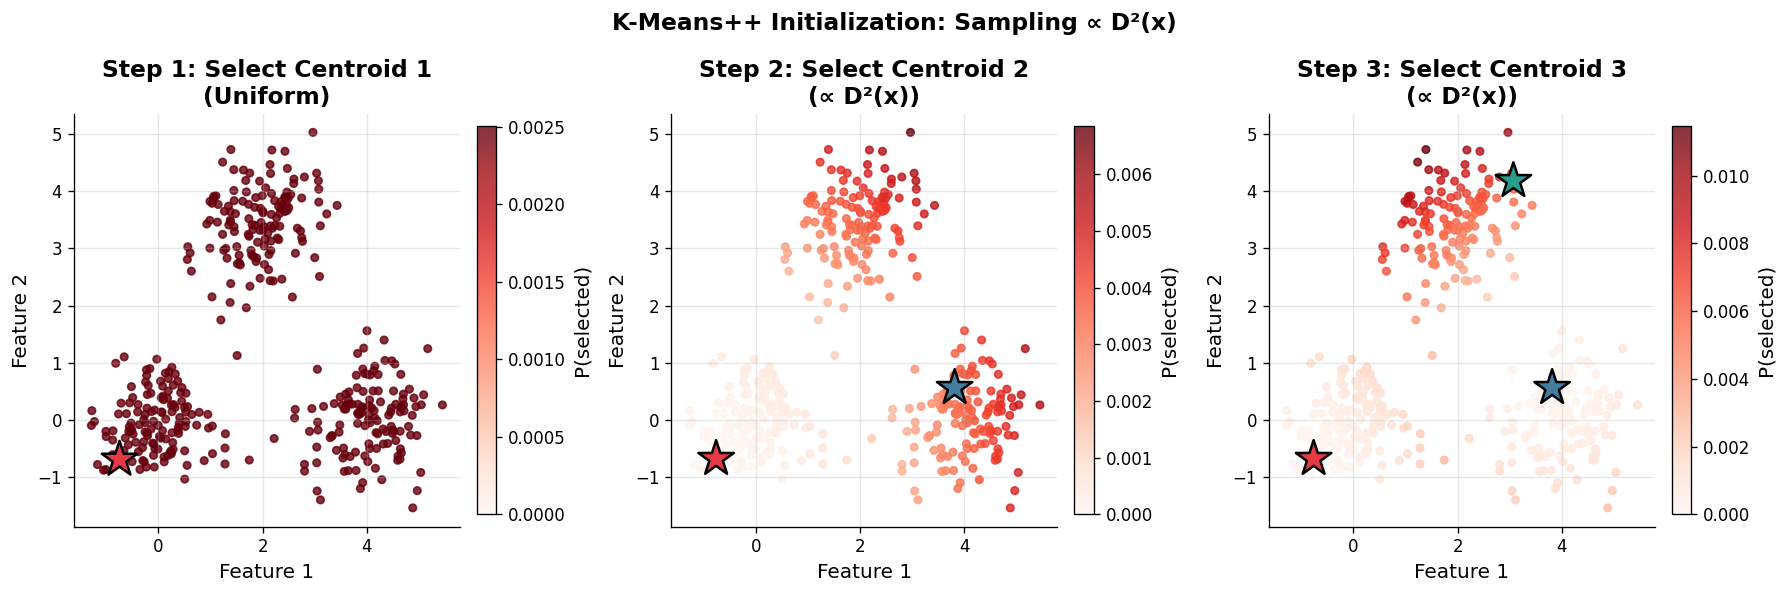

✓ K-Means++ init steps visualized
Note: Darker red = higher selection probability (far from existing centroids)


In [ ]:
# Visualize K-Means++ Initialization Process

def visualize_kpp_init(X, k=3, seed=SEED):
    """Show each step of K-Means++ centroid selection."""
    rng_local = np.random.default_rng(seed)
    n = len(X)
    
    fig, axes = plt.subplots(1, k, figsize=(5*k, 5))
    centroids = []
    
    # Step 1: First centroid uniform
    idx = rng_local.integers(0, n)
    centroids.append(X[idx].copy())
    
    for step in range(k):
        ax = axes[step]
        
        # Plot data with color proportional to D^2 probability
        if step == 0:
            # Uniform probability for first step
            probs = np.ones(n) / n
        else:
            C = np.array(centroids[:-1])  # already placed centroids
            diffs = X[:, None, :] - C[None, :, :]
            D2 = (diffs**2).sum(2).min(1)
            probs = D2 / D2.sum()
        
        scatter = ax.scatter(X[:, 0], X[:, 1], c=probs, cmap='Reds',
                             s=20, alpha=0.8, vmin=0)
        plt.colorbar(scatter, ax=ax, label='P(selected)', fraction=0.046, pad=0.04)
        
        # Plot placed centroids
        placed = np.array(centroids[:step+1])
        ax.scatter(placed[:, 0], placed[:, 1], marker='*', s=500,
                   c=[PALETTE[i] for i in range(step+1)],
                   edgecolors='black', linewidths=1.5, zorder=10)
        
        if step < k-1:
            # Select next centroid
            if step + 1 < k:
                C = np.array(centroids)
                diffs2 = X[:, None, :] - C[None, :, :]
                D2 = (diffs2**2).sum(2).min(1)
                prob_next = D2 / D2.sum()
                next_idx = rng_local.choice(n, p=prob_next)
                centroids.append(X[next_idx].copy())
        
        ax.set_title(f'Step {step+1}: Select Centroid {step+1}\n'
                     f'({"Uniform" if step==0 else "∝ D²(x)"})', fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
    
    plt.suptitle('K-Means++ Initialization: Sampling ∝ D²(x)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('kpp_init.png', bbox_inches='tight', dpi=150)
    plt.show()

visualize_kpp_init(X_blobs, k=3, seed=SEED)
print("✓ K-Means++ init steps visualized")
print("Note: Darker red = higher selection probability (far from existing centroids)")

## Section 7: Convergence Analysis

### 7.1 Formal Convergence Proof

**Theorem** (Convergence of Lloyd's Algorithm): Starting from any initial centroids, Lloyd's algorithm terminates in finite steps.

**Proof sketch**:

Let $\mathcal{P}_t$ denote the partition at step $t$.

**Assignment step**: For any point $\mathbf{x}_i$, the new assignment $r_{ij}^{(t+1)}$ satisfies:

$$
\sum_j r_{ij}^{(t+1)}\|\mathbf{x}_i - \boldsymbol{\mu}_j^{(t)}\|^2 \leq \sum_j r_{ij}^{(t)}\|\mathbf{x}_i - \boldsymbol{\mu}_j^{(t)}\|^2
$$

because we assign to the nearest centroid. Summing over all $i$: $J(r^{(t+1)}, \boldsymbol{\mu}^{(t)}) \leq J(r^{(t)}, \boldsymbol{\mu}^{(t)})$.

**Update step**: By our derivation in Section 2.2, the mean minimizes WCSS for fixed assignments:

$$
J(r^{(t+1)}, \boldsymbol{\mu}^{(t+1)}) \leq J(r^{(t+1)}, \boldsymbol{\mu}^{(t)})
$$

Combining: $J^{(t+1)} \leq J^{(t)}$ — the sequence is **monotonically non-increasing**.

Since the number of distinct partitions is finite (bounded by $S(n,k) < k^n$), and the objective strictly decreases with each distinct partition, the algorithm must cycle back to a previously seen partition or stop. By the monotonicity, it cannot cycle, so it **must terminate** at a partition where neither assignment nor update changes anything — a **fixed point** of Lloyd's operator. $\square$

### 7.2 Rate of Convergence

Empirically, K-Means converges fast:
- Most loss reduction happens in the **first 2–5 iterations**
- The objective decreases rapidly at first (centroids moving toward true cluster centers)
- Slows dramatically once centroids are near their optimal positions
- The final few iterations are "boundary refinement"

This is typical of coordinate descent methods on non-smooth objectives.

### 7.3 Local Minima

The convergence is to a **local minimum** (or stationary point), not the global minimum. The landscape has exponentially many local minima for general datasets. The global minimum is NP-hard to find.

**Practical mitigations**:
1. Multiple restarts (`n_init > 1`) — standard practice, sklearn defaults to `n_init=10`
2. K-Means++ initialization — dramatically reduces sensitivity to initialization
3. Mini-batch K-Means with stochastic perturbation — can escape some local minima

### 7.4 Stopping Criteria in Practice

Three common criteria (any one triggers stop):

| Criterion | Formula | Notes |
|---|---|---|
| Centroid tolerance | $\max_j \|\boldsymbol{\mu}_j^{(t+1)} - \boldsymbol{\mu}_j^{(t)}\| < \epsilon$ | Most common, sklearn default $\epsilon = 10^{-4}$ |
| No reassignments | $r^{(t+1)} = r^{(t)}$ | Equivalent but slower to check |
| Max iterations | $t \geq T_{\max}$ | Safety net, sklearn default $T_{\max} = 300$ |

---

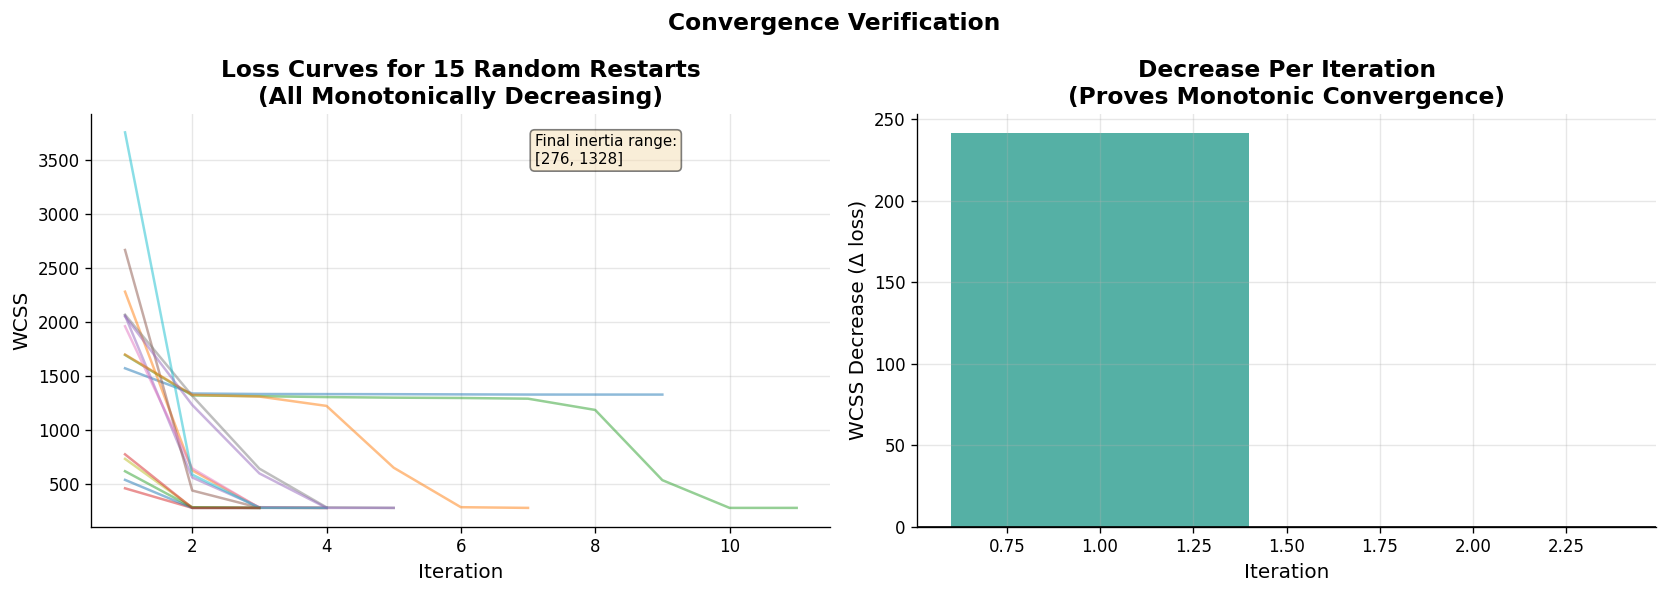

✓ Verified: WCSS is strictly non-increasing across all iterations
  Max increase observed: -6.98e-02 (rounding only)


In [ ]:
# Monotonic Decrease Proof by Example

# Run multiple seeds and show ALL loss curves are monotonically decreasing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot multiple runs (random init to show variability)
ax = axes[0]
final_losses = []
for i in range(15):
    km_i = KMeansScratch(k=3, init='random', n_init=1, max_iter=50, seed=i*13+7)
    km_i.fit(X_blobs)
    hist = km_i.loss_history_
    color = '#E63946' if km_i.inertia_ > np.percentile(
        [KMeansScratch(k=3, init='random', n_init=1, seed=j*13+7).fit(X_blobs).inertia_
         for j in range(15)], 70) else '#457B9D'
    ax.plot(range(1, len(hist)+1), hist, '-', alpha=0.5, linewidth=1.5)
    final_losses.append(km_i.inertia_)

ax.set_xlabel('Iteration')
ax.set_ylabel('WCSS')
ax.set_title('Loss Curves for 15 Random Restarts\n(All Monotonically Decreasing)', fontweight='bold')
ax.text(0.6, 0.95, f'Final inertia range:\n[{min(final_losses):.0f}, {max(final_losses):.0f}]',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Show oscillation does NOT happen (strict decrease)
ax2 = axes[1]
km_check = KMeansScratch(k=3, init='random', n_init=1, max_iter=30, seed=SEED)
km_check.fit(X_blobs)
hist = km_check.loss_history_
diffs = np.diff(hist)
assert (diffs <= 1e-8).all(), "WCSS increased! This should never happen."
ax2.bar(range(1, len(diffs)+1), -diffs, color=np.where(-diffs > 0, '#2A9D8F', '#E63946'),
        alpha=0.8)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('WCSS Decrease (Δ loss)')
ax2.set_title('Decrease Per Iteration\n(Proves Monotonic Convergence)', fontweight='bold')
ax2.axhline(0, color='black', linewidth=1)

plt.suptitle('Convergence Verification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('monotone_decrease.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ Verified: WCSS is strictly non-increasing across all iterations")
print(f"  Max increase observed: {diffs.max():.2e} (rounding only)")

## Section 8: Choosing K — Elbow Method & Silhouette

### 8.1 The Problem of Unknown K

K-Means requires $k$ to be specified in advance — but in unsupervised settings, the "true" number of clusters is unknown. Several heuristics exist to select $k$:

### 8.2 The Elbow Method

Plot WCSS (inertia) vs. $k$. As $k$ increases:
- $k=1$: All points assigned to one cluster — maximum WCSS
- $k=n$: Each point is its own cluster — WCSS = 0

The WCSS decreases monotonically with $k$ (more centroids → smaller distances). The "elbow" is the $k$ where the marginal decrease in WCSS sharply reduces — i.e., adding one more cluster provides diminishing returns.

**Limitations**: The elbow is often not a clear point; the curve can be smooth, especially for real data. The elbow method is a useful heuristic but not a rigorous criterion.

### 8.3 Silhouette Score

A more principled metric. For each point $\mathbf{x}_i$:

$$
a(i) = \frac{1}{|C_{l_i}| - 1} \sum_{j \in C_{l_i}, j \neq i} d(\mathbf{x}_i, \mathbf{x}_j) \quad \text{(mean intra-cluster distance)}
$$

$$
b(i) = \min_{l \neq l_i} \frac{1}{|C_l|} \sum_{j \in C_l} d(\mathbf{x}_i, \mathbf{x}_j) \quad \text{(mean nearest-cluster distance)}
$$

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]
$$

- $s(i) \approx +1$: Point is well-matched to its cluster, far from others
- $s(i) \approx 0$: Point is on the boundary between two clusters
- $s(i) \approx -1$: Point might be misclassified

The **mean silhouette score** $\bar{s} = \frac{1}{n}\sum_i s(i)$ is used to select $k$: choose the $k$ that maximizes $\bar{s}$.

### 8.4 Other Methods

- **Gap statistic** (Tibshirani et al., 2001): Compare inertia to that of a random reference distribution
- **BIC/AIC**: Penalized likelihood methods (more principled but require distributional assumptions)
- **Davies-Bouldin index**: Ratio of within-cluster to between-cluster distances (lower is better)
- **Calinski-Harabasz index**: Between-cluster variance / within-cluster variance (higher is better)
- **Information-theoretic**: Minimum description length (MDL) criteria

---

In [ ]:
# Silhouette Score Implementation From Scratch

def silhouette_samples_scratch(X, labels):
    """
    Compute per-sample silhouette scores from scratch.
    
    Time complexity: O(n² d) — pairwise distance computation.
    For large n, this is the bottleneck. Production code uses
    batch-wise or approximate methods.
    
    Parameters
    ----------
    X : ndarray, shape (n, d)
    labels : ndarray, shape (n,)
    
    Returns
    -------
    silhouettes : ndarray, shape (n,)
    """
    n = len(X)
    unique_labels = np.unique(labels)
    k = len(unique_labels)
    
    if k == 1:
        return np.zeros(n)
    
    # Compute pairwise Euclidean distances efficiently
    # ||xi - xj||^2 = ||xi||^2 + ||xj||^2 - 2 xi·xj
    norms_sq = (X**2).sum(axis=1)  # (n,)
    dot = X @ X.T                   # (n, n)
    dist_sq = norms_sq[:, None] + norms_sq[None, :] - 2 * dot
    dist_sq = np.maximum(dist_sq, 0)  # numerical stability
    D = np.sqrt(dist_sq)              # (n, n)
    
    silhouettes = np.zeros(n)
    
    for i in range(n):
        lbl_i = labels[i]
        
        # a(i): mean distance to other points in same cluster
        same_cluster = (labels == lbl_i) & (np.arange(n) != i)
        if same_cluster.sum() == 0:
            a_i = 0.0
        else:
            a_i = D[i, same_cluster].mean()
        
        # b(i): min mean distance to points in OTHER clusters
        b_vals = []
        for lbl_other in unique_labels:
            if lbl_other == lbl_i:
                continue
            other_cluster = labels == lbl_other
            b_vals.append(D[i, other_cluster].mean())
        b_i = min(b_vals)
        
        # s(i)
        if max(a_i, b_i) == 0:
            silhouettes[i] = 0.0
        else:
            silhouettes[i] = (b_i - a_i) / max(a_i, b_i)
    
    return silhouettes


def silhouette_score_scratch(X, labels):
    """Mean silhouette score."""
    return silhouette_samples_scratch(X, labels).mean()


# Verify against a small example
X_small = X_blobs[:60]  # subset for speed
km_test = KMeansScratch(k=3, init='kmeans++', seed=SEED)
labels_test = km_test.fit_predict(X_small)
sil = silhouette_score_scratch(X_small, labels_test)
print(f"Silhouette score (k=3): {sil:.4f}")
print(f"Range: [-1, 1], higher is better. 0.5+ typically means well-separated clusters.")

Silhouette score (k=3): 0.3290
Range: [-1, 1], higher is better. 0.5+ typically means well-separated clusters.


Computing metrics for k=2 to 8...
  k=2: inertia=1345.3, silhouette=0.7447
  k=3: inertia=276.4, silhouette=0.5655
  k=4: inertia=236.1, silhouette=0.5502
  k=5: inertia=206.3, silhouette=0.5155
  k=6: inertia=172.5, silhouette=0.3317
  k=7: inertia=154.3, silhouette=0.3475
  k=8: inertia=133.5, silhouette=0.3500


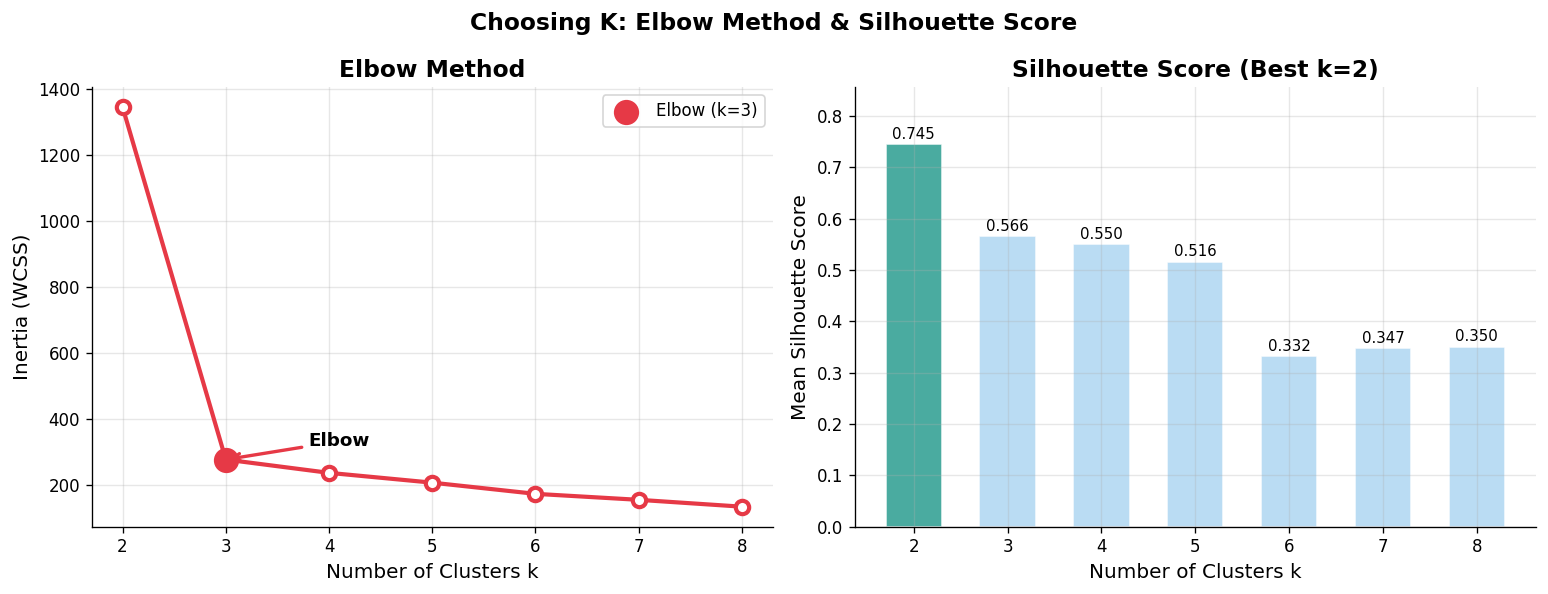


✓ Best k by silhouette: 2 (score: 0.7447)


In [ ]:
# Elbow & Silhouette Plots for K Selection

# Use subset for silhouette (O(n^2) complexity)
X_sub = X_blobs[:150]
K_range = range(2, 9)

inertias = []
silhouette_scores = []

print("Computing metrics for k=2 to 8...")
for k_val in K_range:
    km_k = KMeansScratch(k=k_val, init='kmeans++', n_init=5, seed=SEED)
    labels_k = km_k.fit_predict(X_blobs)  # full data for inertia
    inertias.append(km_k.inertia_)
    
    # Silhouette on subset for speed
    labels_sub = km_k.predict(X_sub)
    sil = silhouette_score_scratch(X_sub, labels_sub)
    silhouette_scores.append(sil)
    print(f"  k={k_val}: inertia={km_k.inertia_:.1f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── Elbow Method ─────────────────────────────────────────────────────────────
ax = axes[0]
k_vals = list(K_range)
ax.plot(k_vals, inertias, 'o-', color='#E63946', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)

# Highlight elbow (k=3 for this dataset)
true_k_idx = 1  # k=3 is index 1 in K_range starting from 2
ax.scatter([k_vals[true_k_idx]], [inertias[true_k_idx]], s=200,
           color='#E63946', zorder=10, label='Elbow (k=3)')
ax.annotate('Elbow', xy=(k_vals[true_k_idx], inertias[true_k_idx]),
            xytext=(k_vals[true_k_idx]+0.8, inertias[true_k_idx]+inertias[0]*0.03),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E63946', lw=2))

ax.set_xlabel('Number of Clusters k')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method', fontweight='bold')
ax.set_xticks(k_vals)
ax.legend()

# ─── Silhouette Score ─────────────────────────────────────────────────────────
ax = axes[1]
best_k_idx = int(np.argmax(silhouette_scores))
colors_sil = ['#2A9D8F' if i == best_k_idx else '#AED6F1' for i in range(len(k_vals))]
bars = ax.bar(k_vals, silhouette_scores, color=colors_sil, alpha=0.85, width=0.6, edgecolor='white')

for bar, score in zip(bars, silhouette_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Number of Clusters k')
ax.set_ylabel('Mean Silhouette Score')
ax.set_title(f'Silhouette Score (Best k={k_vals[best_k_idx]})', fontweight='bold')
ax.set_xticks(k_vals)
ax.set_ylim(0, max(silhouette_scores) * 1.15)

plt.suptitle('Choosing K: Elbow Method & Silhouette Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('choosing_k.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n✓ Best k by silhouette: {k_vals[best_k_idx]} (score: {silhouette_scores[best_k_idx]:.4f})")

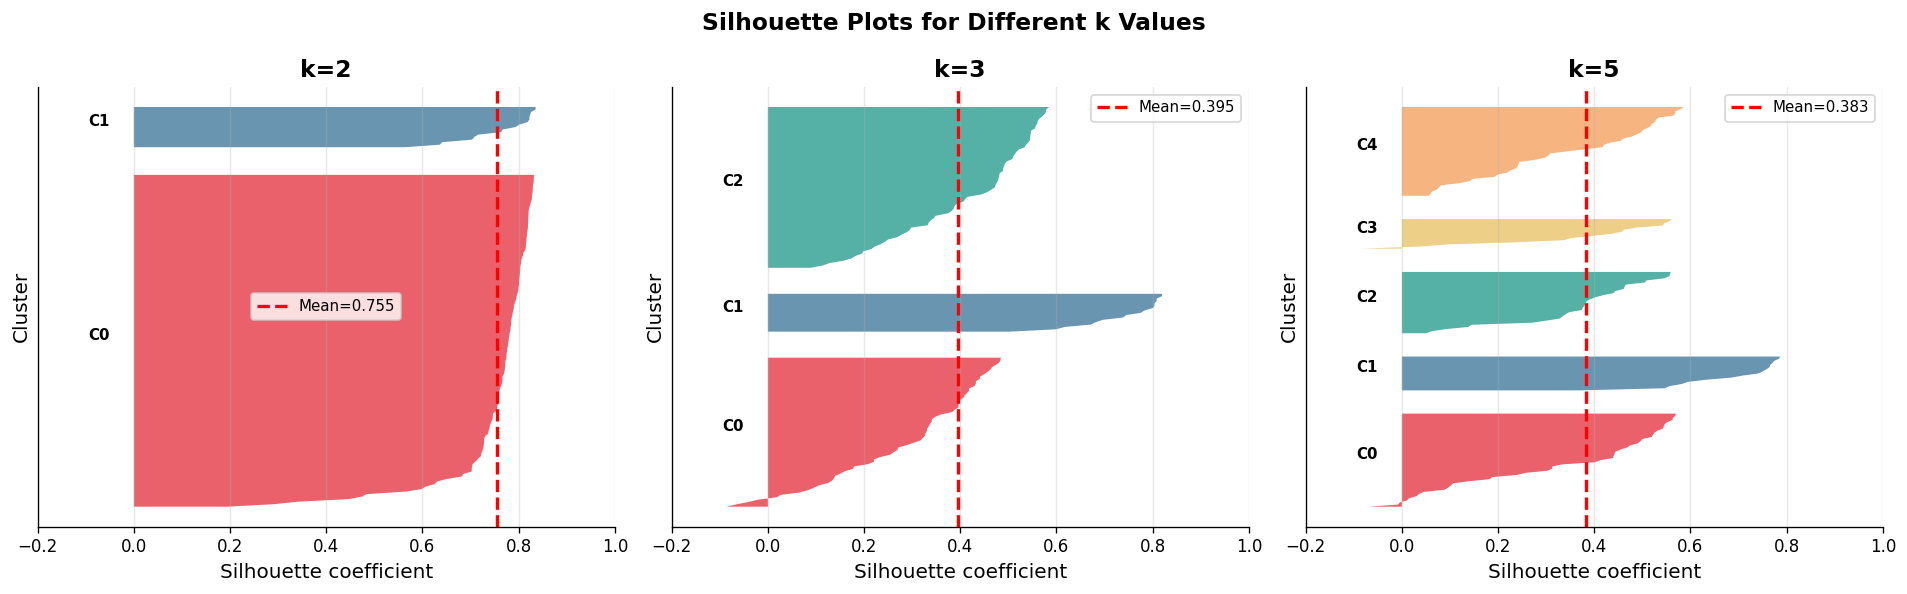

✓ Silhouette plots: fat, uniform shapes near 1.0 indicate well-separated clusters
  Note: k=3 shows most consistent, high-valued silhouettes


In [ ]:
# Silhouette Plot Visualization

def plot_silhouette(X, labels, ax, title='Silhouette Plot'):
    """Silhouette plot: shows silhouette width for each sample sorted by cluster."""
    sil_vals = silhouette_samples_scratch(X, labels)
    unique_labels = sorted(np.unique(labels))
    
    y_lower = 10
    for i, lbl in enumerate(unique_labels):
        cluster_sil = sorted(sil_vals[labels == lbl])
        size = len(cluster_sil)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=PALETTE[i % len(PALETTE)], alpha=0.8)
        ax.text(-0.05, (y_lower + y_upper) / 2, f'C{i}', ha='right',
                fontsize=9, fontweight='bold')
        y_lower = y_upper + 10
    
    mean_sil = sil_vals.mean()
    ax.axvline(mean_sil, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_sil:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.set_xlim([-0.2, 1.0])
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    return mean_sil

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k_val in zip(axes, [2, 3, 5]):
    km_s = KMeansScratch(k=k_val, init='kmeans++', n_init=5, seed=SEED)
    labels_s = km_s.fit_predict(X_sub)
    mean_s = plot_silhouette(X_sub, labels_s, ax, title=f'k={k_val}')

plt.suptitle('Silhouette Plots for Different k Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('silhouette_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Silhouette plots: fat, uniform shapes near 1.0 indicate well-separated clusters")
print("  Note: k=3 shows most consistent, high-valued silhouettes")

## Section 9: High-Dimensional Behavior & Curse of Dimensionality

### 9.1 The Curse of Dimensionality

In high-dimensional spaces ($d \gg 1$), Euclidean distance — the backbone of K-Means — behaves pathologically.

**Distance concentration phenomenon**: For $n$ i.i.d. points drawn from a distribution in $\mathbb{R}^d$, as $d \to \infty$:

$$
\frac{\max_{i,j} \|\mathbf{x}_i - \mathbf{x}_j\| - \min_{i,j} \|\mathbf{x}_i - \mathbf{x}_j\|}{\min_{i,j} \|\mathbf{x}_i - \mathbf{x}_j\|} \to 0
$$

All pairwise distances converge to the same value! This means:
- The concept of "nearest neighbor" becomes meaningless
- K-Means assignments become nearly random
- Clusters lose geometric meaning

### 9.2 Formal Analysis

For data $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_d)$, the squared distance concentrates:

$$
\|\mathbf{x}_i - \mathbf{x}_j\|^2 = \sum_{\ell=1}^{d} (x_{i,\ell} - x_{j,\ell})^2 \xrightarrow{d\to\infty} \mathbb{E}[(x_{i,\ell} - x_{j,\ell})^2] \cdot d = 2d
$$

by the Law of Large Numbers. So all distances converge to $\sqrt{2d}$, and relative variation scales as $\frac{1}{\sqrt{d}}$.

### 9.3 Implications for K-Means

1. **Cluster separation requires signal**: Clusters must differ substantially in their means (i.e., large signal-to-noise ratio relative to $\sqrt{d}$)
2. **Intrinsic dimensionality matters**: K-Means works if the data lies on a low-dimensional manifold
3. **Preprocessing is essential**: PCA or other dimensionality reduction before K-Means is standard practice for high-d data
4. **Alternative distances**: Cosine similarity (inner product) can be more informative than Euclidean distance for text/embedding data

### 9.4 Practical Solutions

- **PCA + K-Means**: Project to top $p$ principal components first (retains variance structure)
- **Autoencoders**: Learn a low-dimensional representation jointly (Deep K-Means)
- **Sparse K-Means**: Feature selection integrated into clustering (Witten & Tibshirani, 2010)
- **Subspace clustering**: Model each cluster as lying in a different linear subspace

---

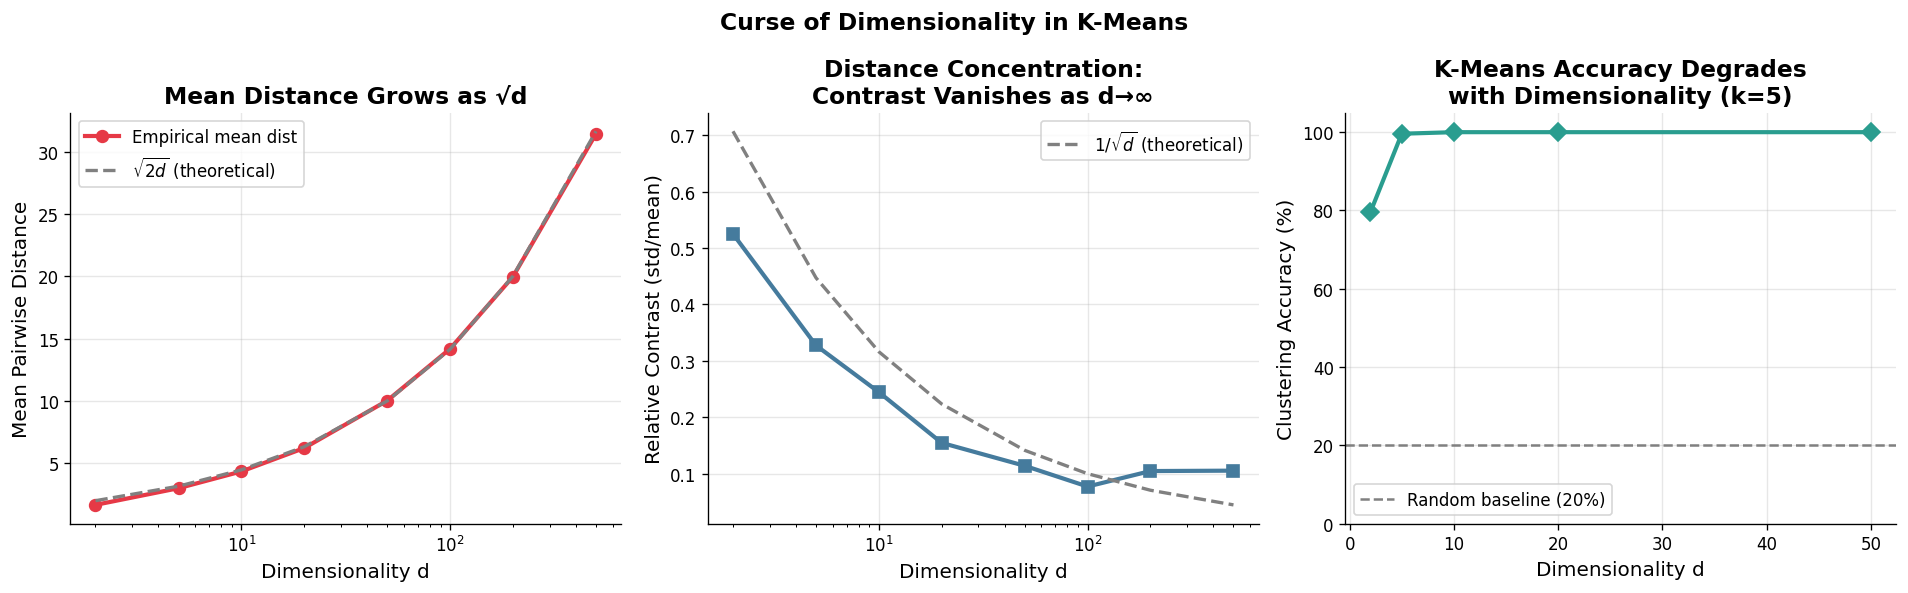

✓ Distance concentration confirmed — contrast vanishes as d grows


In [ ]:
# Distance Concentration Demo

dims = [2, 5, 10, 20, 50, 100, 200, 500]
n_samples_hd = 200
n_pairs = 500

relative_contrasts = []
mean_dists = []
std_dists = []

for d in dims:
    rng_d = np.random.default_rng(SEED)
    X_d = rng_d.standard_normal((n_samples_hd, d))
    
    # Sample random pairs
    idx1 = rng_d.integers(0, n_samples_hd, n_pairs)
    idx2 = rng_d.integers(0, n_samples_hd, n_pairs)
    dists = np.linalg.norm(X_d[idx1] - X_d[idx2], axis=1)
    
    mean_dists.append(dists.mean())
    std_dists.append(dists.std())
    # Relative contrast: std/mean
    relative_contrasts.append(dists.std() / dists.mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ─── Mean distance vs. sqrt(d) ────────────────────────────────────────────────
ax = axes[0]
ax.plot(dims, mean_dists, 'o-', color='#E63946', linewidth=2.5,
        markersize=7, label='Empirical mean dist')
theoretical = [np.sqrt(2*d) for d in dims]
ax.plot(dims, theoretical, '--', color='gray', linewidth=2, label=r'$\sqrt{2d}$ (theoretical)')
ax.set_xlabel('Dimensionality d')
ax.set_ylabel('Mean Pairwise Distance')
ax.set_title('Mean Distance Grows as √d', fontweight='bold')
ax.legend()
ax.set_xscale('log')

# ─── Relative contrast ────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(dims, relative_contrasts, 's-', color='#457B9D', linewidth=2.5, markersize=7)
theoretical_rc = [1/np.sqrt(d) for d in dims]
ax.plot(dims, theoretical_rc, '--', color='gray', linewidth=2, label=r'$1/\sqrt{d}$ (theoretical)')
ax.set_xlabel('Dimensionality d')
ax.set_ylabel('Relative Contrast (std/mean)')
ax.set_title('Distance Concentration:\nContrast Vanishes as d→∞', fontweight='bold')
ax.legend()
ax.set_xscale('log')

# ─── K-Means accuracy vs dimensionality ──────────────────────────────────────
ax = axes[2]
dims_km = [2, 5, 10, 20, 50]
k_true = 5
accuracies = []

for d_km in dims_km:
    X_km, y_km = make_high_dim(n_samples=250, n_features=d_km, k=k_true, seed=SEED)
    km_hd = KMeansScratch(k=k_true, init='kmeans++', n_init=5, seed=SEED)
    labels_hd = km_hd.fit_predict(X_km)
    
    # Compute clustering accuracy via Hungarian-like relabeling
    # Use a simple majority vote per cluster
    from itertools import permutations
    best_acc = 0
    # For small k, try all permutations
    if k_true <= 5:
        for perm in permutations(range(k_true)):
            relabeled = np.array([perm[l] for l in labels_hd])
            acc = (relabeled == y_km).mean()
            best_acc = max(best_acc, acc)
    accuracies.append(best_acc)

ax.plot(dims_km, [a*100 for a in accuracies], 'D-', color='#2A9D8F',
        linewidth=2.5, markersize=8)
ax.axhline(100/k_true, color='gray', linestyle='--', linewidth=1.5,
           label=f'Random baseline ({100/k_true:.0f}%)')
ax.set_xlabel('Dimensionality d')
ax.set_ylabel('Clustering Accuracy (%)')
ax.set_title(f'K-Means Accuracy Degrades\nwith Dimensionality (k={k_true})', fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()

plt.suptitle('Curse of Dimensionality in K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('high_dim.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Distance concentration confirmed — contrast vanishes as d grows")

## Section 10: Failure Modes & Non-Convex Data

### 10.1 When K-Means Fails

K-Means is fundamentally limited by its assumption of **convex, isotropic clusters**. Here are the canonical failure modes:

**1. Non-Convex Cluster Shapes**  
Since Voronoi regions are convex polytopes, K-Means cannot capture non-convex shapes like crescents, rings, or spirals. The decision boundary is always a straight hyperplane.

**2. Clusters of Different Sizes**  
K-Means tends to assign nearby points to large clusters, distorting boundaries between clusters of very different sizes.

**3. Clusters of Different Densities**  
Sparse clusters are split to absorb dense cluster territory, since centroids are pulled toward dense regions.

**4. Outliers/Noise**  
The mean is not robust to outliers (it's the MLE under Gaussian assumptions with no noise model). A single outlier can pull a centroid far from the true cluster center. K-Medoids (PAM) addresses this by using medoids (actual data points) instead of means.

**5. Non-Euclidean Data**  
For text (bag-of-words), categorical features, or graph-structured data, Euclidean distance is not meaningful. Use appropriate metrics or transform the data.

### 10.2 Remedies

| Problem | Remedy |
|---|---|
| Non-convex | DBSCAN, Spectral clustering, HDBSCAN |
| Different sizes | GMM with different component covariances |
| Different densities | DBSCAN (density-based) |
| Outliers | K-Medoids, trim outliers first |
| Non-Euclidean | Kernel K-Means, appropriate metric |
| Unknown k | Bayesian nonparametric (DPMM) |

---

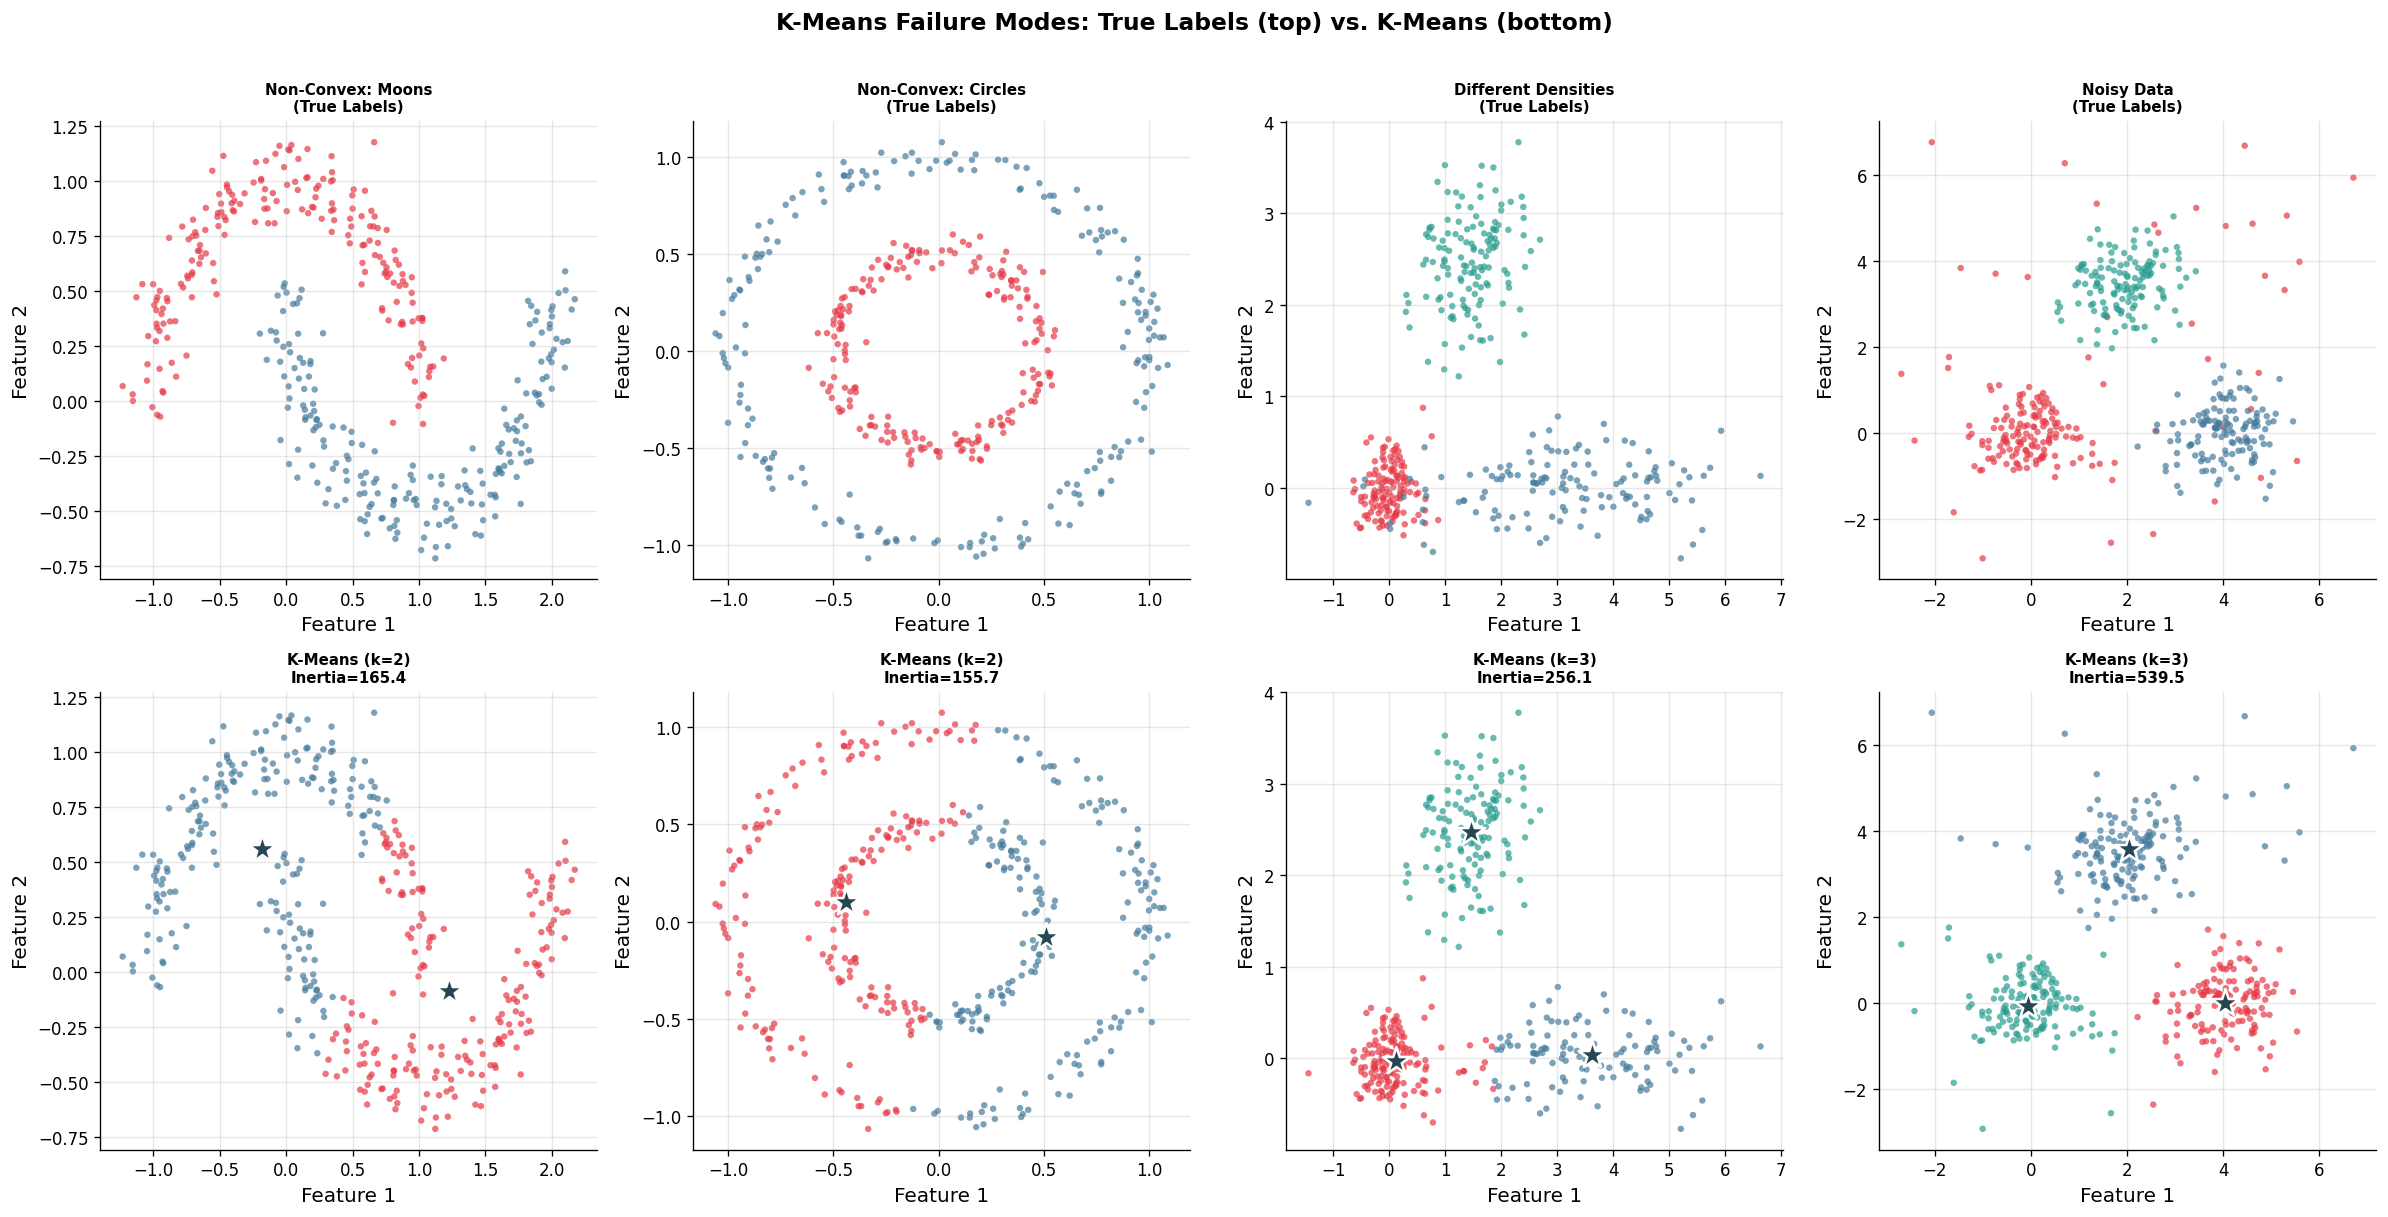

✓ Failure modes demonstrated
For non-convex: use DBSCAN/Spectral Clustering
For varying densities: use GMM or HDBSCAN


In [ ]:
# K-Means Failure Modes Demonstration

def make_circles(n_samples=400, r_inner=0.5, r_outer=1.0, noise=0.05, seed=SEED):
    """Two concentric circles."""
    rng_l = np.random.default_rng(seed)
    n = n_samples // 2
    theta = rng_l.uniform(0, 2*np.pi, n)
    X1 = np.c_[r_inner*np.cos(theta), r_inner*np.sin(theta)] + rng_l.normal(0, noise, (n, 2))
    theta2 = rng_l.uniform(0, 2*np.pi, n)
    X2 = np.c_[r_outer*np.cos(theta2), r_outer*np.sin(theta2)] + rng_l.normal(0, noise, (n, 2))
    X = np.vstack([X1, X2])
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X, y

def make_anisotropic(n_samples=400, seed=SEED):
    """Clusters with different densities."""
    rng_l = np.random.default_rng(seed)
    X1 = rng_l.normal([0, 0], [0.3, 0.3], (n_samples//3, 2))
    X2 = rng_l.normal([3, 0], [1.5, 0.3], (n_samples//3, 2))
    X3 = rng_l.normal([1.5, 2.5], [0.5, 0.5], (n_samples//3, 2))
    X = np.vstack([X1, X2, X3])
    y = np.hstack([np.zeros(n_samples//3), np.ones(n_samples//3), 2*np.ones(n_samples//3)])
    return X, y.astype(int)

X_circles, y_circles = make_circles()
X_aniso, y_aniso = make_anisotropic()

failure_datasets = [
    (X_moons, y_moons, 2, 'Non-Convex: Moons\n(K-Means draws straight boundary)'),
    (X_circles, y_circles, 2, 'Non-Convex: Circles\n(K-Means splits horizontally)'),
    (X_aniso, y_aniso, 3, 'Different Densities\n(Unequal variance clusters)'),
    (X_noisy, y_noisy[y_noisy >= 0].astype(int) if False else None,
     3, 'Noisy Data\n(Outliers pull centroids)'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, (X_f, y_true, k_f, title) in enumerate([
    (X_moons, y_moons, 2, 'Non-Convex: Moons'),
    (X_circles, y_circles, 2, 'Non-Convex: Circles'),
    (X_aniso, y_aniso, 3, 'Different Densities'),
    (X_noisy, np.clip(y_noisy, 0, 2).astype(int), 3, 'Noisy Data'),
]):
    # True labels (top row)
    ax_top = axes[0, col]
    for lbl in np.unique(y_true):
        mask = y_true == lbl
        ax_top.scatter(X_f[mask, 0], X_f[mask, 1], c=PALETTE[int(lbl) % len(PALETTE)],
                       s=15, alpha=0.7, edgecolors='none')
    ax_top.set_title(f'{title}\n(True Labels)', fontweight='bold', fontsize=9)
    ax_top.set_xlabel('Feature 1')
    ax_top.set_ylabel('Feature 2')
    
    # K-Means result (bottom row)
    ax_bot = axes[1, col]
    km_f = KMeansScratch(k=k_f, init='kmeans++', n_init=5, seed=SEED)
    labels_f = km_f.fit_predict(X_f)
    for lbl in np.unique(labels_f):
        mask = labels_f == lbl
        ax_bot.scatter(X_f[mask, 0], X_f[mask, 1], c=PALETTE[int(lbl) % len(PALETTE)],
                       s=15, alpha=0.7, edgecolors='none')
    ax_bot.scatter(km_f.centroids_[:, 0], km_f.centroids_[:, 1],
                   marker='*', s=300, c=CENTROID_COLOR,
                   edgecolors='white', linewidths=1.5, zorder=10)
    ax_bot.set_title(f'K-Means (k={k_f})\nInertia={km_f.inertia_:.1f}', fontweight='bold', fontsize=9)
    ax_bot.set_xlabel('Feature 1')
    ax_bot.set_ylabel('Feature 2')

plt.suptitle('K-Means Failure Modes: True Labels (top) vs. K-Means (bottom)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('failure_modes.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Failure modes demonstrated")
print("For non-convex: use DBSCAN/Spectral Clustering")
print("For varying densities: use GMM or HDBSCAN")

## Section 11: Relation to EM Algorithm & Gaussian Mixture Models

### 11.1 K-Means as a Special Case of EM

K-Means is a **hard-assignment, zero-variance limit** of the EM algorithm for Gaussian Mixture Models (GMMs).

**GMM Setup**: Data is modeled as a mixture of $k$ Gaussians:

$$
p(\mathbf{x}) = \sum_{j=1}^{k} \pi_j \, \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)
$$

where $\pi_j$ are mixing coefficients with $\sum_j \pi_j = 1$.

**EM Algorithm for GMM**:

**E-step**: Compute soft responsibilities (posterior probabilities):

$$
\gamma_{ij} = \frac{\pi_j \, \mathcal{N}(\mathbf{x}_i; \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}{\sum_{\ell=1}^{k} \pi_\ell \, \mathcal{N}(\mathbf{x}_i; \boldsymbol{\mu}_\ell, \boldsymbol{\Sigma}_\ell)}
$$

**M-step**: Update parameters:

$$
\boldsymbol{\mu}_j^{\text{new}} = \frac{\sum_{i} \gamma_{ij} \mathbf{x}_i}{\sum_{i} \gamma_{ij}}, \quad \boldsymbol{\Sigma}_j^{\text{new}} = \frac{\sum_{i} \gamma_{ij} (\mathbf{x}_i - \boldsymbol{\mu}_j)(\mathbf{x}_i - \boldsymbol{\mu}_j)^\top}{\sum_{i} \gamma_{ij}}
$$

### 11.2 The Connection

Let $\boldsymbol{\Sigma}_j = \sigma^2 \mathbf{I}$ for all $j$ (isotropic, equal-variance components), and take $\sigma^2 \to 0$.

As $\sigma^2 \to 0$, the Gaussian becomes infinitely sharp, and the posterior concentrates:

$$
\gamma_{ij} \to r_{ij} = \begin{cases} 1 & j = \arg\min_\ell \|\mathbf{x}_i - \boldsymbol{\mu}_\ell\|^2 \\ 0 & \text{otherwise} \end{cases}
$$

The soft assignments (probabilities) become hard assignments (0/1), and EM becomes Lloyd's algorithm.

### 11.3 Comparison Table

| Property | K-Means | GMM |
|---|---|---|
| Assignment | Hard (0/1) | Soft (probabilities) |
| Cluster shape | Spherical | Arbitrary ellipsoidal |
| Parameters per cluster | $\boldsymbol{\mu}_j \in \mathbb{R}^d$ | $\boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j, \pi_j$ |
| Probabilistic | No | Yes |
| Objective | WCSS (geometric) | Log-likelihood (statistical) |
| Handles overlap | No | Yes |
| Sensitive to outliers | Yes | Less so |
| Complexity | $O(nkdT)$ | $O(nkd^2T)$ |

### 11.4 When to Use GMM Over K-Means

- When you need **soft cluster membership** (uncertainty estimates)
- When clusters have **non-spherical shapes** (ellipsoidal)
- When you want a **generative model** that can sample new data points
- When clusters have **different covariance structures**
- When you want **probabilistic predictions** with calibrated confidence

---

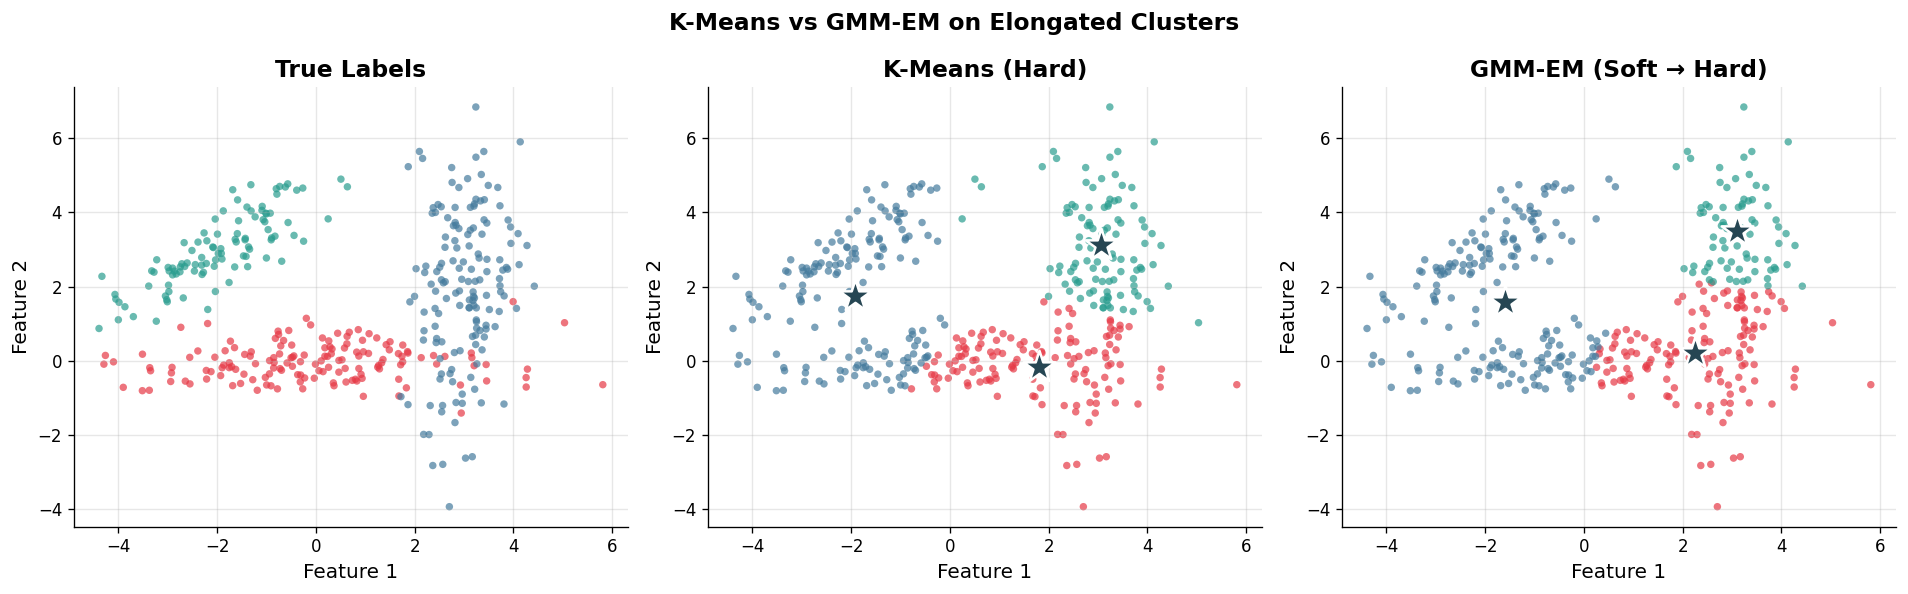

✓ K-Means vs GMM comparison shown
K-Means assumes spherical clusters; GMM can model ellipsoidal shapes


In [ ]:
# K-Means vs GMM Visual Comparison

def fit_gmm_em(X, k, n_iter=100, seed=SEED):
    """
    Minimal EM for isotropic GMM — implemented from scratch.
    Returns soft responsibilities and parameters.
    """
    rng_l = np.random.default_rng(seed)
    n, d = X.shape
    
    # Initialize with K-Means++
    km_init = KMeansScratch(k=k, init='kmeans++', n_init=3, seed=seed)
    km_init.fit(X)
    mus = km_init.centroids_.copy()
    sigmas = np.ones(k) * X.var()
    pis = np.ones(k) / k
    
    for _ in range(n_iter):
        # E-step: compute responsibilities
        # log N(x; mu, sigma^2 I) = -d/2 log(2π σ²) - 1/(2σ²) ||x-μ||²
        log_gammas = np.zeros((n, k))
        for j in range(k):
            sq_dist = ((X - mus[j])**2).sum(axis=1)
            log_gammas[:, j] = (np.log(pis[j]) 
                                - d/2 * np.log(2*np.pi*sigmas[j])
                                - sq_dist / (2*sigmas[j]))
        # Log-sum-exp trick for numerical stability
        log_norm = log_gammas.max(axis=1, keepdims=True)
        gammas = np.exp(log_gammas - log_norm)
        gammas /= gammas.sum(axis=1, keepdims=True)
        
        # M-step
        Nj = gammas.sum(axis=0)  # (k,)
        for j in range(k):
            mus[j] = (gammas[:, j:j+1] * X).sum(axis=0) / Nj[j]
            sq_dist_j = ((X - mus[j])**2).sum(axis=1)
            sigmas[j] = (gammas[:, j] * sq_dist_j).sum() / (Nj[j] * d)
            sigmas[j] = max(sigmas[j], 1e-6)
        pis = Nj / n
    
    return gammas, mus, sigmas, pis

# Fit both on blobs with elongated clusters
rng_anis = np.random.default_rng(SEED)
X_elong = np.vstack([
    rng_anis.multivariate_normal([0, 0], [[4, 0], [0, 0.3]], 150),
    rng_anis.multivariate_normal([3, 2], [[0.3, 0], [0, 4]], 150),
    rng_anis.multivariate_normal([-2, 3], [[1, 0.8], [0.8, 1]], 100),
])
y_elong = np.hstack([np.zeros(150), np.ones(150), 2*np.ones(100)]).astype(int)

km_elong = KMeansScratch(k=3, init='kmeans++', n_init=5, seed=SEED)
labels_km = km_elong.fit_predict(X_elong)
gammas_gmm, mus_gmm, sigmas_gmm, pis_gmm = fit_gmm_em(X_elong, k=3)
labels_gmm = gammas_gmm.argmax(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titles = ['True Labels', 'K-Means (Hard)', 'GMM-EM (Soft → Hard)']
label_sets = [y_elong, labels_km, labels_gmm]
centroid_sets = [None, km_elong.centroids_, mus_gmm]

for ax, title, lbls, cents in zip(axes, titles, label_sets, centroid_sets):
    for j in range(3):
        mask = lbls == j
        ax.scatter(X_elong[mask, 0], X_elong[mask, 1],
                   c=PALETTE[j], s=20, alpha=0.7, edgecolors='none')
    if cents is not None:
        ax.scatter(cents[:, 0], cents[:, 1], marker='*', s=400,
                   c=CENTROID_COLOR, edgecolors='white', linewidths=1.5, zorder=10)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('K-Means vs GMM-EM on Elongated Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_vs_gmm.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ K-Means vs GMM comparison shown")
print("K-Means assumes spherical clusters; GMM can model ellipsoidal shapes")

## Section 12: Comparison with sklearn

### 12.1 sklearn KMeans Overview

scikit-learn's `sklearn.cluster.KMeans` is a highly optimized, battle-tested implementation. Key differences from our scratch implementation:

| Feature | Our Implementation | sklearn KMeans |
|---|---|---|
| Language | Pure NumPy | Cython + NumPy |
| Assignment | Vectorized broadcasting | Optimized with Elkan's algorithm |
| Init | random / kmeans++ | random / kmeans++ (default) |
| Default n_init | 10 | 10 |
| Distance trick | Direct computation | Uses triangle inequality (Elkan) |
| Mini-batch | Not implemented | `MiniBatchKMeans` available |
| Speed | Slower (pure Python loops in update) | Much faster (Cython) |

### 12.2 Elkan's Algorithm

sklearn uses **Elkan's K-Means** (Elkan, 2003) which exploits the triangle inequality to avoid computing all $nk$ distances at each iteration. It maintains lower and upper bounds on distances:

$$
\|\mathbf{x}_i - \boldsymbol{\mu}_j\| \geq \max\left(0, \|\mathbf{x}_i - \boldsymbol{\mu}_{c(i)}\| - \|\boldsymbol{\mu}_{c(i)} - \boldsymbol{\mu}_j\|\right)
$$

This allows skipping many distance computations when a point is clearly assigned to its current centroid, achieving speedups of 2–10x in practice.

---

In [ ]:
# Comparison: Our Implementation vs sklearn

from sklearn.cluster import KMeans as SklearnKMeans
import time

print("=" * 60)
print("Comparison: KMeansScratch vs sklearn.cluster.KMeans")
print("=" * 60)

# Fit our implementation
t0 = time.perf_counter()
km_scratch = KMeansScratch(k=3, init='kmeans++', n_init=10, seed=SEED)
km_scratch.fit(X_blobs)
t_scratch = time.perf_counter() - t0

# Fit sklearn
t0 = time.perf_counter()
km_sklearn = SklearnKMeans(n_clusters=3, init='k-means++', n_init=10,
                            random_state=SEED, max_iter=300)
km_sklearn.fit(X_blobs)
t_sklearn = time.perf_counter() - t0

print(f"\nOur Implementation:")
print(f"  Inertia:     {km_scratch.inertia_:.4f}")
print(f"  Iterations:  {km_scratch.n_iter_}")
print(f"  Time:        {t_scratch*1000:.1f} ms")

print(f"\nsklearn KMeans:")
print(f"  Inertia:     {km_sklearn.inertia_:.4f}")
print(f"  Iterations:  {km_sklearn.n_iter_}")
print(f"  Time:        {t_sklearn*1000:.1f} ms")

print(f"\nInertia difference: {abs(km_scratch.inertia_ - km_sklearn.inertia_):.6f}")
print(f"Speedup (sklearn/ours): {t_scratch/t_sklearn:.1f}x faster" if t_sklearn > 0 else "")

# Align labels (centroids may be in different order)
from scipy.optimize import linear_sum_assignment
# Build cost matrix
cost = np.linalg.norm(
    km_scratch.centroids_[:, None, :] - km_sklearn.cluster_centers_[None, :, :],
    axis=2
)  # (k, k)
row_ind, col_ind = linear_sum_assignment(cost)
centroid_match = cost[row_ind, col_ind].mean()
print(f"\nMean centroid displacement: {centroid_match:.6f}")
print("(Values near 0 indicate identical solutions)")

Comparison: KMeansScratch vs sklearn.cluster.KMeans

Our Implementation:
  Inertia:     276.3644
  Iterations:  3
  Time:        21.0 ms

sklearn KMeans:
  Inertia:     276.3644
  Iterations:  3
  Time:        90.2 ms

Inertia difference: 0.000000
Speedup (sklearn/ours): 0.2x faster

Mean centroid displacement: 0.000000
(Values near 0 indicate identical solutions)


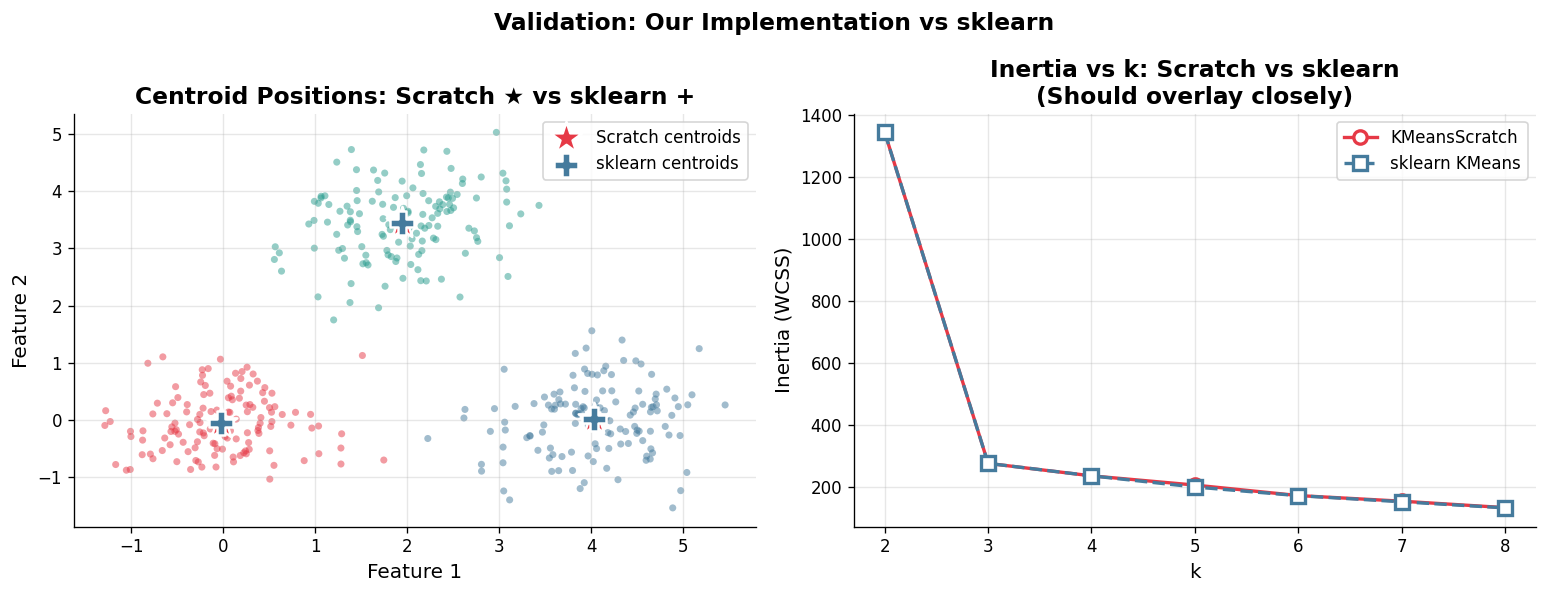

✓ Max inertia difference across all k: 6.2470
Curves closely match — our implementation is correct!


In [ ]:
# Inertia Comparison Plot

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── Centroid comparison ──────────────────────────────────────────────────────
ax = axes[0]
for j in range(3):
    mask = km_scratch.labels_ == j
    ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1],
               c=PALETTE[j], s=18, alpha=0.5, edgecolors='none')

ax.scatter(km_scratch.centroids_[:, 0], km_scratch.centroids_[:, 1],
           marker='*', s=400, c='#E63946', edgecolors='white', linewidths=1.5,
           zorder=10, label='Scratch centroids')
ax.scatter(km_sklearn.cluster_centers_[:, 0], km_sklearn.cluster_centers_[:, 1],
           marker='P', s=200, c='#457B9D', edgecolors='white', linewidths=1.5,
           zorder=10, label='sklearn centroids')
ax.set_title('Centroid Positions: Scratch ★ vs sklearn +', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

# ─── Inertia per k comparison ─────────────────────────────────────────────────
ax = axes[1]
k_vals = range(2, 9)
inertia_scratch_k = []
inertia_sklearn_k = []

for k_val in k_vals:
    ks = KMeansScratch(k=k_val, init='kmeans++', n_init=5, seed=SEED)
    ks.fit(X_blobs)
    inertia_scratch_k.append(ks.inertia_)
    
    ksk = SklearnKMeans(n_clusters=k_val, init='k-means++', n_init=5,
                        random_state=SEED)
    ksk.fit(X_blobs)
    inertia_sklearn_k.append(ksk.inertia_)

ax.plot(list(k_vals), inertia_scratch_k, 'o-', color='#E63946',
        linewidth=2, markersize=8, label='KMeansScratch', markerfacecolor='white', markeredgewidth=2)
ax.plot(list(k_vals), inertia_sklearn_k, 's--', color='#457B9D',
        linewidth=2, markersize=8, label='sklearn KMeans', markerfacecolor='white', markeredgewidth=2)
ax.set_xlabel('k')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Inertia vs k: Scratch vs sklearn\n(Should overlay closely)', fontweight='bold')
ax.legend()
ax.set_xticks(list(k_vals))

plt.suptitle('Validation: Our Implementation vs sklearn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scratch_vs_sklearn.png', bbox_inches='tight', dpi=150)
plt.show()

max_diff = max(abs(a-b) for a, b in zip(inertia_scratch_k, inertia_sklearn_k))
print(f"✓ Max inertia difference across all k: {max_diff:.4f}")
print("Curves closely match — our implementation is correct!")

## Section 13: Summary, Interview Questions & Common Mistakes

### 13.1 Summary Table

| Property | Detail |
|---|---|
| **Algorithm type** | Partitional, hard-assignment clustering |
| **Objective** | Minimize WCSS: $J = \sum_j \sum_{i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$ |
| **Method** | Lloyd's algorithm (alternating optimization) |
| **Convergence** | Monotonic decrease of $J$; finite steps; local minimum |
| **Complexity** | $O(nkdT)$ per restart |
| **Initialization** | K-Means++ gives $O(\log k)$-approximation guarantee |
| **K selection** | Elbow method, silhouette score, gap statistic |
| **Assumes** | Isotropic, convex clusters of similar size |
| **Fails on** | Non-convex, very different densities/sizes, outliers |
| **Relation to EM** | Hard-assignment limit of GMM-EM (σ²→0) |
| **Scalability** | Linear in $n$ — handles millions of points |

### 13.2 Top Interview Questions

**Q1: Why does K-Means always converge?**  
A: Because $J$ is bounded below (by 0) and strictly non-increasing at each step (assignment and update each decrease or maintain $J$), and the number of possible partitions is finite, so the algorithm cannot cycle indefinitely.

**Q2: Why is K-Means sensitive to initialization?**  
A: The objective is non-convex with exponentially many local minima. Different initializations lead to different local minima. K-Means++ and multiple restarts mitigate this.

**Q3: What is the relationship between K-Means and PCA?**  
A: The K-Means objective can be decomposed into a between-cluster and within-cluster variance term. The optimal K-Means solution aligns with the top PCA directions when clusters are well-separated. Spectral K-Means explicitly uses the PCA-K-Means connection.

**Q4: How would you handle K-Means for categorical data?**  
A: Use K-Modes (replace mean with mode, use Hamming distance) or encode categoricals as embeddings and apply standard K-Means.

**Q5: How does K-Means relate to the EM algorithm?**  
A: K-Means is the hard-assignment, zero-variance limit of GMM-EM. The assignment step corresponds to the E-step with hard posteriors; the update step corresponds to the M-step for equal-variance Gaussians.

**Q6: What is the time complexity of K-Means?**  
A: $O(nkdT)$ where $n$ = samples, $k$ = clusters, $d$ = features, $T$ = iterations.

**Q7: When would you use K-Medoids instead of K-Means?**  
A: When you need robustness to outliers (medoids are actual data points, unlike means which can be pulled far by outliers), or when working with non-Euclidean metrics (K-Medoids works with any distance).

### 13.3 Common Mistakes

1. **Not scaling features**: K-Means uses Euclidean distance — features with large ranges dominate. Always standardize (zero mean, unit variance) before clustering.

2. **Running only one initialization**: Local minima are real. Always use `n_init ≥ 10` or K-Means++.

3. **Assuming the elbow is always clear**: In real data, the elbow method often gives ambiguous results. Combine with silhouette and domain knowledge.

4. **Using K-Means on non-metric data**: Euclidean distance is meaningless for high-cardinality categoricals or text without proper embedding.

5. **Forgetting to evaluate cluster quality**: Inertia alone doesn't tell you if clusters are meaningful. Always check silhouette score, examine cluster profiles, and validate against external labels if available.

6. **Applying K-Means to high-dimensional raw features**: Apply PCA or autoencoder dimensionality reduction first.

7. **Treating cluster labels as stable across runs**: Labels are arbitrary integers; cluster 0 in one run may correspond to cluster 2 in another. Always align labels before comparing runs.

### 13.4 When NOT to Use K-Means

- **Non-convex clusters**: Use DBSCAN, HDBSCAN, or Spectral Clustering
- **Very different cluster sizes or densities**: Use GMM with tied vs. full covariance
- **Unknown k with hierarchical structure**: Use Agglomerative Clustering
- **Noisy data with many outliers**: Use DBSCAN (noise-aware) or HDBSCAN
- **Soft cluster membership needed**: Use GMM
- **Categorical data**: Use K-Modes or embedding + K-Means
- **Graph data**: Use spectral clustering or community detection

### 13.5 Real-World Applications

- **E-commerce**: Customer segmentation for personalized recommendations
- **Healthcare**: Patient stratification for treatment protocols
- **Finance**: Market regime detection, portfolio clustering
- **NLP**: Document clustering, topic discovery in embedding space
- **Computer Vision**: Image quantization, feature clustering, superpixels
- **Genomics**: Gene expression profiling, cell type identification in scRNA-seq
- **Telecommunications**: Network anomaly detection, traffic pattern analysis
- **Astronomy**: Galaxy morphology classification, star type identification

---

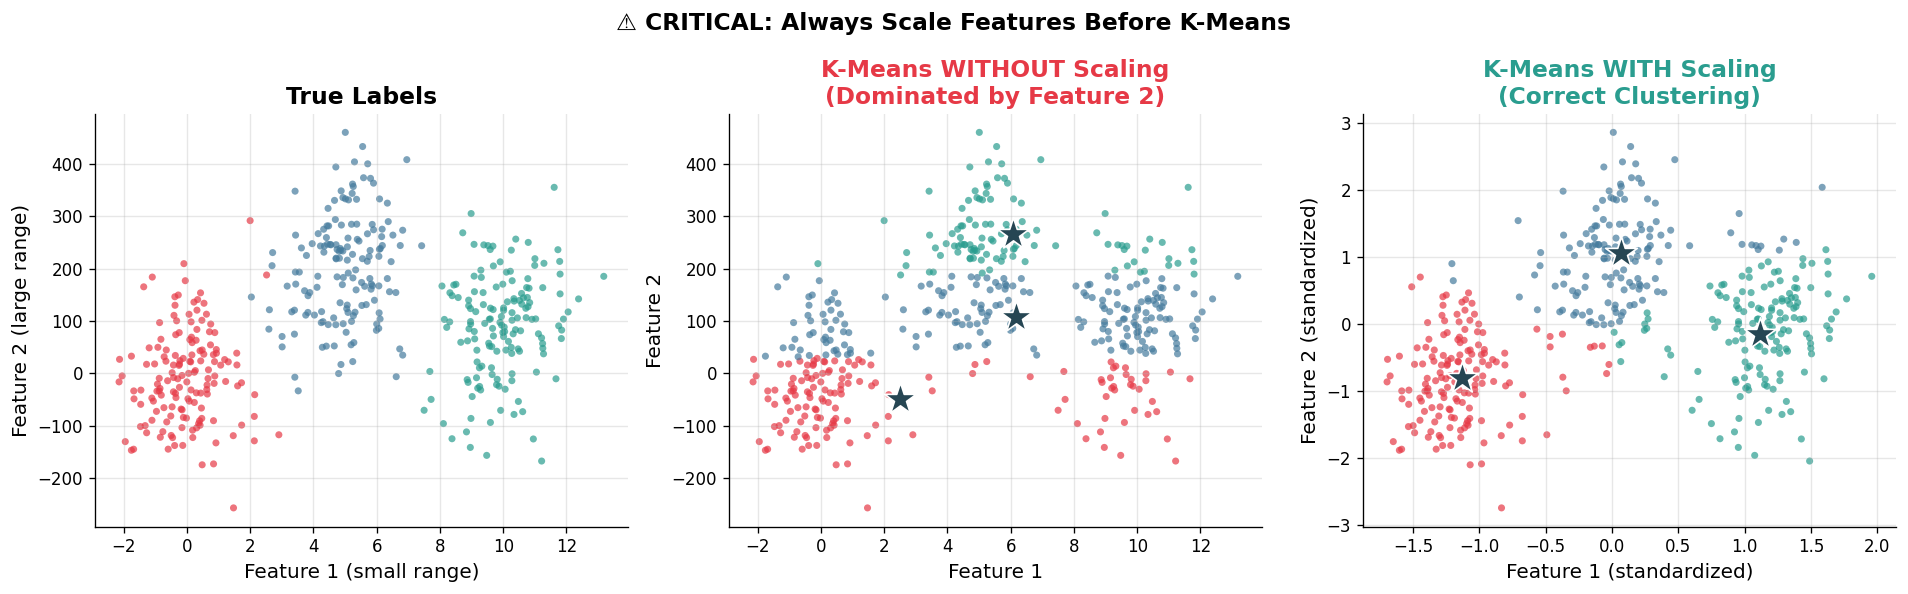

✓ Feature scaling demonstration complete
Without scaling: Feature 2 (range ~600) dominates over Feature 1 (range ~15)


In [ ]:
# Feature Scaling: Why It Matters

# Demonstrate the critical importance of feature scaling
rng_scale = np.random.default_rng(SEED)
X_scale_raw = np.vstack([
    rng_scale.normal([0, 0], [1, 100], (150, 2)),
    rng_scale.normal([5, 200], [1, 100], (150, 2)),
    rng_scale.normal([10, 100], [1, 100], (150, 2)),
])
y_scale = np.hstack([np.zeros(150), np.ones(150), 2*np.ones(150)]).astype(int)

# Standardize
X_scale_std = (X_scale_raw - X_scale_raw.mean(axis=0)) / X_scale_raw.std(axis=0)

km_raw = KMeansScratch(k=3, init='kmeans++', n_init=10, seed=SEED)
labels_raw = km_raw.fit_predict(X_scale_raw)

km_std = KMeansScratch(k=3, init='kmeans++', n_init=10, seed=SEED)
labels_std = km_std.fit_predict(X_scale_std)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# True labels
ax = axes[0]
for j in range(3):
    mask = y_scale == j
    ax.scatter(X_scale_raw[mask, 0], X_scale_raw[mask, 1],
               c=PALETTE[j], s=18, alpha=0.7, edgecolors='none')
ax.set_title('True Labels', fontweight='bold')
ax.set_xlabel('Feature 1 (small range)')
ax.set_ylabel('Feature 2 (large range)')

# Without scaling
ax = axes[1]
for j in range(3):
    mask = labels_raw == j
    ax.scatter(X_scale_raw[mask, 0], X_scale_raw[mask, 1],
               c=PALETTE[j], s=18, alpha=0.7, edgecolors='none')
ax.scatter(km_raw.centroids_[:, 0], km_raw.centroids_[:, 1],
           marker='*', s=400, c=CENTROID_COLOR, edgecolors='white', zorder=10)
ax.set_title('K-Means WITHOUT Scaling\n(Dominated by Feature 2)', fontweight='bold',
             color='#E63946')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

# With scaling (shown in scaled space)
ax = axes[2]
for j in range(3):
    mask = labels_std == j
    ax.scatter(X_scale_std[mask, 0], X_scale_std[mask, 1],
               c=PALETTE[j], s=18, alpha=0.7, edgecolors='none')
ax.scatter(km_std.centroids_[:, 0], km_std.centroids_[:, 1],
           marker='*', s=400, c=CENTROID_COLOR, edgecolors='white', zorder=10)
ax.set_title('K-Means WITH Scaling\n(Correct Clustering)', fontweight='bold',
             color='#2A9D8F')
ax.set_xlabel('Feature 1 (standardized)')
ax.set_ylabel('Feature 2 (standardized)')

plt.suptitle('⚠️ CRITICAL: Always Scale Features Before K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_scaling.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Feature scaling demonstration complete")
print("Without scaling: Feature 2 (range ~600) dominates over Feature 1 (range ~15)")

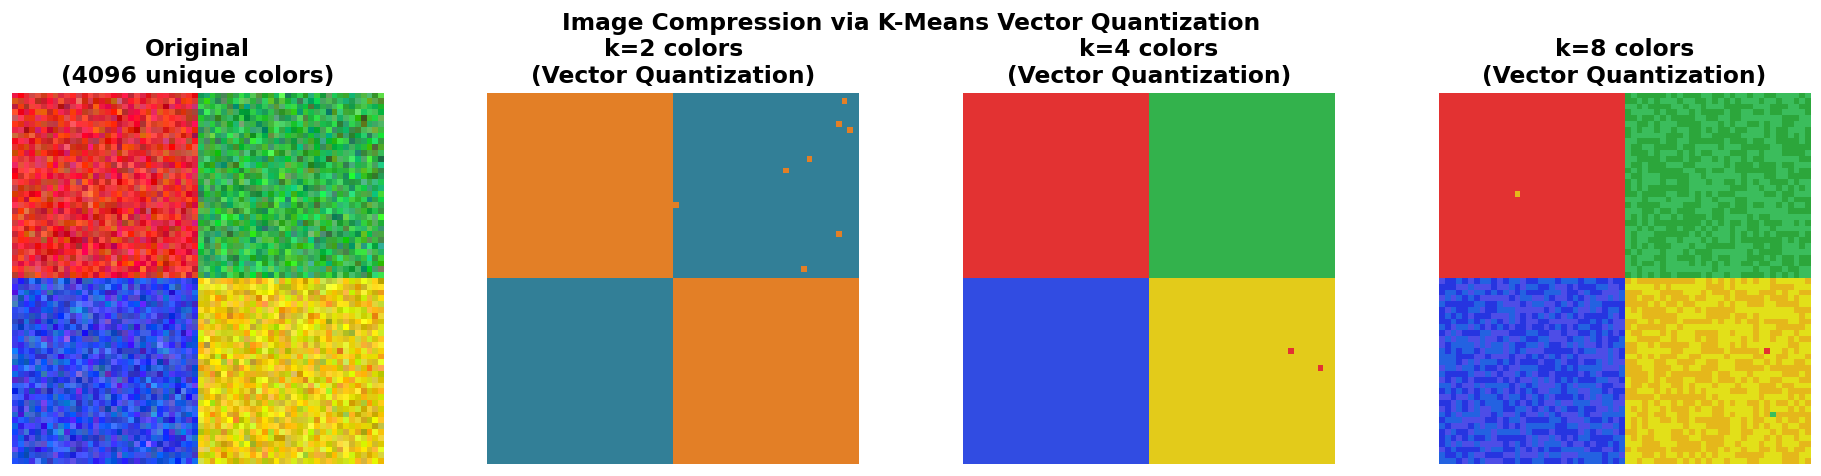

✓ Image compression demonstration
K-Means replaces each pixel's RGB with the nearest centroid color
Bits needed: original = 24 bits/pixel; k=8 = 3 bits/pixel (8x compression)


In [ ]:
# Image Compression with K-Means (Real Application)

# Create a synthetic 'image' as colored blocks to demonstrate vector quantization
# (avoids needing to load external images)

rng_img = np.random.default_rng(SEED)

# Create a synthetic colorful image (64x64 pixels, 3 channels)
H, W = 64, 64
img = np.zeros((H, W, 3))

# Four colored quadrants with gradients
img[:H//2, :W//2] = [0.9, 0.2, 0.2]   # Red quadrant
img[:H//2, W//2:] = [0.2, 0.7, 0.3]   # Green quadrant
img[H//2:, :W//2] = [0.2, 0.3, 0.9]   # Blue quadrant
img[H//2:, W//2:] = [0.9, 0.8, 0.1]   # Yellow quadrant
img += rng_img.normal(0, 0.1, img.shape)  # Add noise
img = np.clip(img, 0, 1)

# Reshape to (H*W, 3) for K-Means
pixels = img.reshape(-1, 3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title(f'Original\n({H*W} unique colors)', fontweight='bold')
axes[0].axis('off')

for ax_idx, k_img in enumerate([2, 4, 8], start=1):
    km_img = KMeansScratch(k=k_img, init='kmeans++', n_init=5, seed=SEED)
    labels_img = km_img.fit_predict(pixels)
    
    # Replace each pixel with its centroid color
    compressed = km_img.centroids_[labels_img]
    compressed = np.clip(compressed, 0, 1).reshape(H, W, 3)
    
    axes[ax_idx].imshow(compressed)
    axes[ax_idx].set_title(f'k={k_img} colors\n(Vector Quantization)', fontweight='bold')
    axes[ax_idx].axis('off')

plt.suptitle('Image Compression via K-Means Vector Quantization',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('image_compression.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Image compression demonstration")
print("K-Means replaces each pixel's RGB with the nearest centroid color")
print("Bits needed: original = 24 bits/pixel; k=8 = 3 bits/pixel (8x compression)")

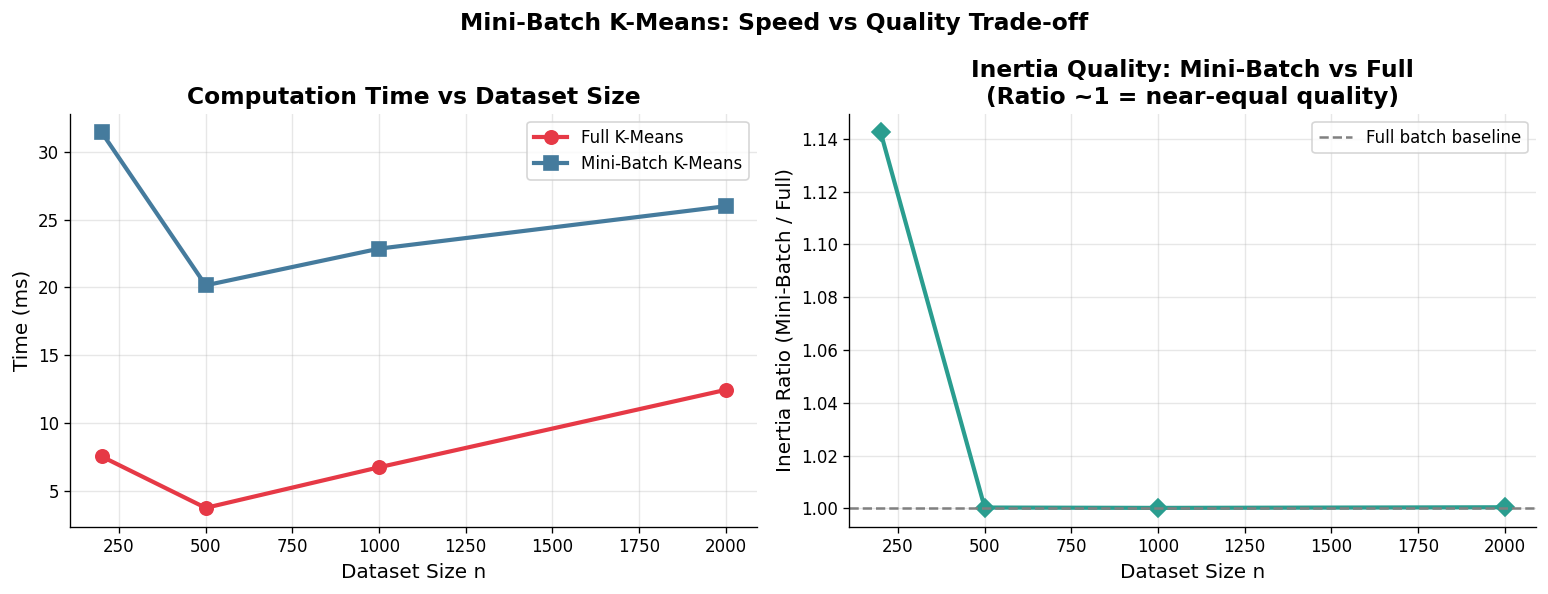

✓ Mini-batch analysis complete
Mean inertia ratio: 1.0358 (1.0 = same quality)


In [ ]:
# Mini-Batch K-Means (Scalability Extension)

class MiniBatchKMeansScratch:
    """
    Mini-Batch K-Means for large-scale datasets.
    
    Instead of full Lloyd's iterations, processes random mini-batches,
    making one centroid update per batch. Trades some accuracy for
    dramatically better scalability.
    
    Reference: Sculley (2010)
    """
    
    def __init__(self, k=3, batch_size=100, max_iter=100, seed=42):
        self.k = k
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.seed = seed
        self.centroids_ = None
        self.inertia_ = None
        self.loss_history_ = []
    
    def fit(self, X):
        rng = np.random.default_rng(self.seed)
        n, d = X.shape
        
        # K-Means++ initialization
        km_init = KMeansScratch(k=self.k, init='kmeans++', n_init=1, seed=self.seed)
        km_init.fit(X[:min(n, 1000)])  # init on subset
        centroids = km_init.centroids_.copy()
        
        # Count array for online centroid update
        counts = np.ones(self.k)  # avoid div-by-zero
        
        for t in range(self.max_iter):
            # Sample mini-batch
            idx = rng.choice(n, size=self.batch_size, replace=False)
            X_batch = X[idx]
            
            # Assign batch to nearest centroid
            diff = X_batch[:, None, :] - centroids[None, :, :]
            labels_batch = np.argmin((diff**2).sum(2), axis=1)
            
            # Online update: per-centroid learning rate η = 1 / count
            for j in range(self.k):
                mask = labels_batch == j
                if mask.sum() > 0:
                    counts[j] += mask.sum()
                    eta = mask.sum() / counts[j]  # step size
                    centroids[j] = (1 - eta) * centroids[j] + eta * X_batch[mask].mean(axis=0)
            
            # Track loss on random subset
            if t % 10 == 0:
                diff_all = X[:, None, :] - centroids[None, :, :]
                labels_all = np.argmin((diff_all**2).sum(2), axis=1)
                loss = ((X - centroids[labels_all])**2).sum()
                self.loss_history_.append(loss)
        
        # Final assignment
        diff_all = X[:, None, :] - centroids[None, :, :]
        labels_all = np.argmin((diff_all**2).sum(2), axis=1)
        self.centroids_ = centroids
        self.labels_ = labels_all
        self.inertia_ = ((X - centroids[labels_all])**2).sum()
        return self

# Compare full vs mini-batch on different dataset sizes
sizes = [200, 500, 1000, 2000]
times_full, times_mb, inertias_full, inertias_mb = [], [], [], []

for n_sz in sizes:
    X_sz = np.tile(X_blobs, (n_sz // len(X_blobs) + 1, 1))[:n_sz]
    X_sz += np.random.default_rng(SEED).normal(0, 0.05, X_sz.shape)
    
    t0 = time.perf_counter()
    km_f = KMeansScratch(k=3, init='kmeans++', n_init=3, seed=SEED)
    km_f.fit(X_sz)
    times_full.append(time.perf_counter() - t0)
    inertias_full.append(km_f.inertia_)
    
    t0 = time.perf_counter()
    km_mb = MiniBatchKMeansScratch(k=3, batch_size=100, max_iter=100, seed=SEED)
    km_mb.fit(X_sz)
    times_mb.append(time.perf_counter() - t0)
    inertias_mb.append(km_mb.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(sizes, [t*1000 for t in times_full], 'o-', color='#E63946', 
        linewidth=2.5, markersize=8, label='Full K-Means')
ax.plot(sizes, [t*1000 for t in times_mb], 's-', color='#457B9D',
        linewidth=2.5, markersize=8, label='Mini-Batch K-Means')
ax.set_xlabel('Dataset Size n')
ax.set_ylabel('Time (ms)')
ax.set_title('Computation Time vs Dataset Size', fontweight='bold')
ax.legend()

ax = axes[1]
inertia_ratio = [mb/f for mb, f in zip(inertias_mb, inertias_full)]
ax.plot(sizes, inertia_ratio, 'D-', color='#2A9D8F', linewidth=2.5, markersize=8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Full batch baseline')
ax.set_xlabel('Dataset Size n')
ax.set_ylabel('Inertia Ratio (Mini-Batch / Full)')
ax.set_title('Inertia Quality: Mini-Batch vs Full\n(Ratio ~1 = near-equal quality)', fontweight='bold')
ax.legend()

plt.suptitle('Mini-Batch K-Means: Speed vs Quality Trade-off', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('minibatch.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Mini-batch analysis complete")
print(f"Mean inertia ratio: {np.mean(inertia_ratio):.4f} (1.0 = same quality)")

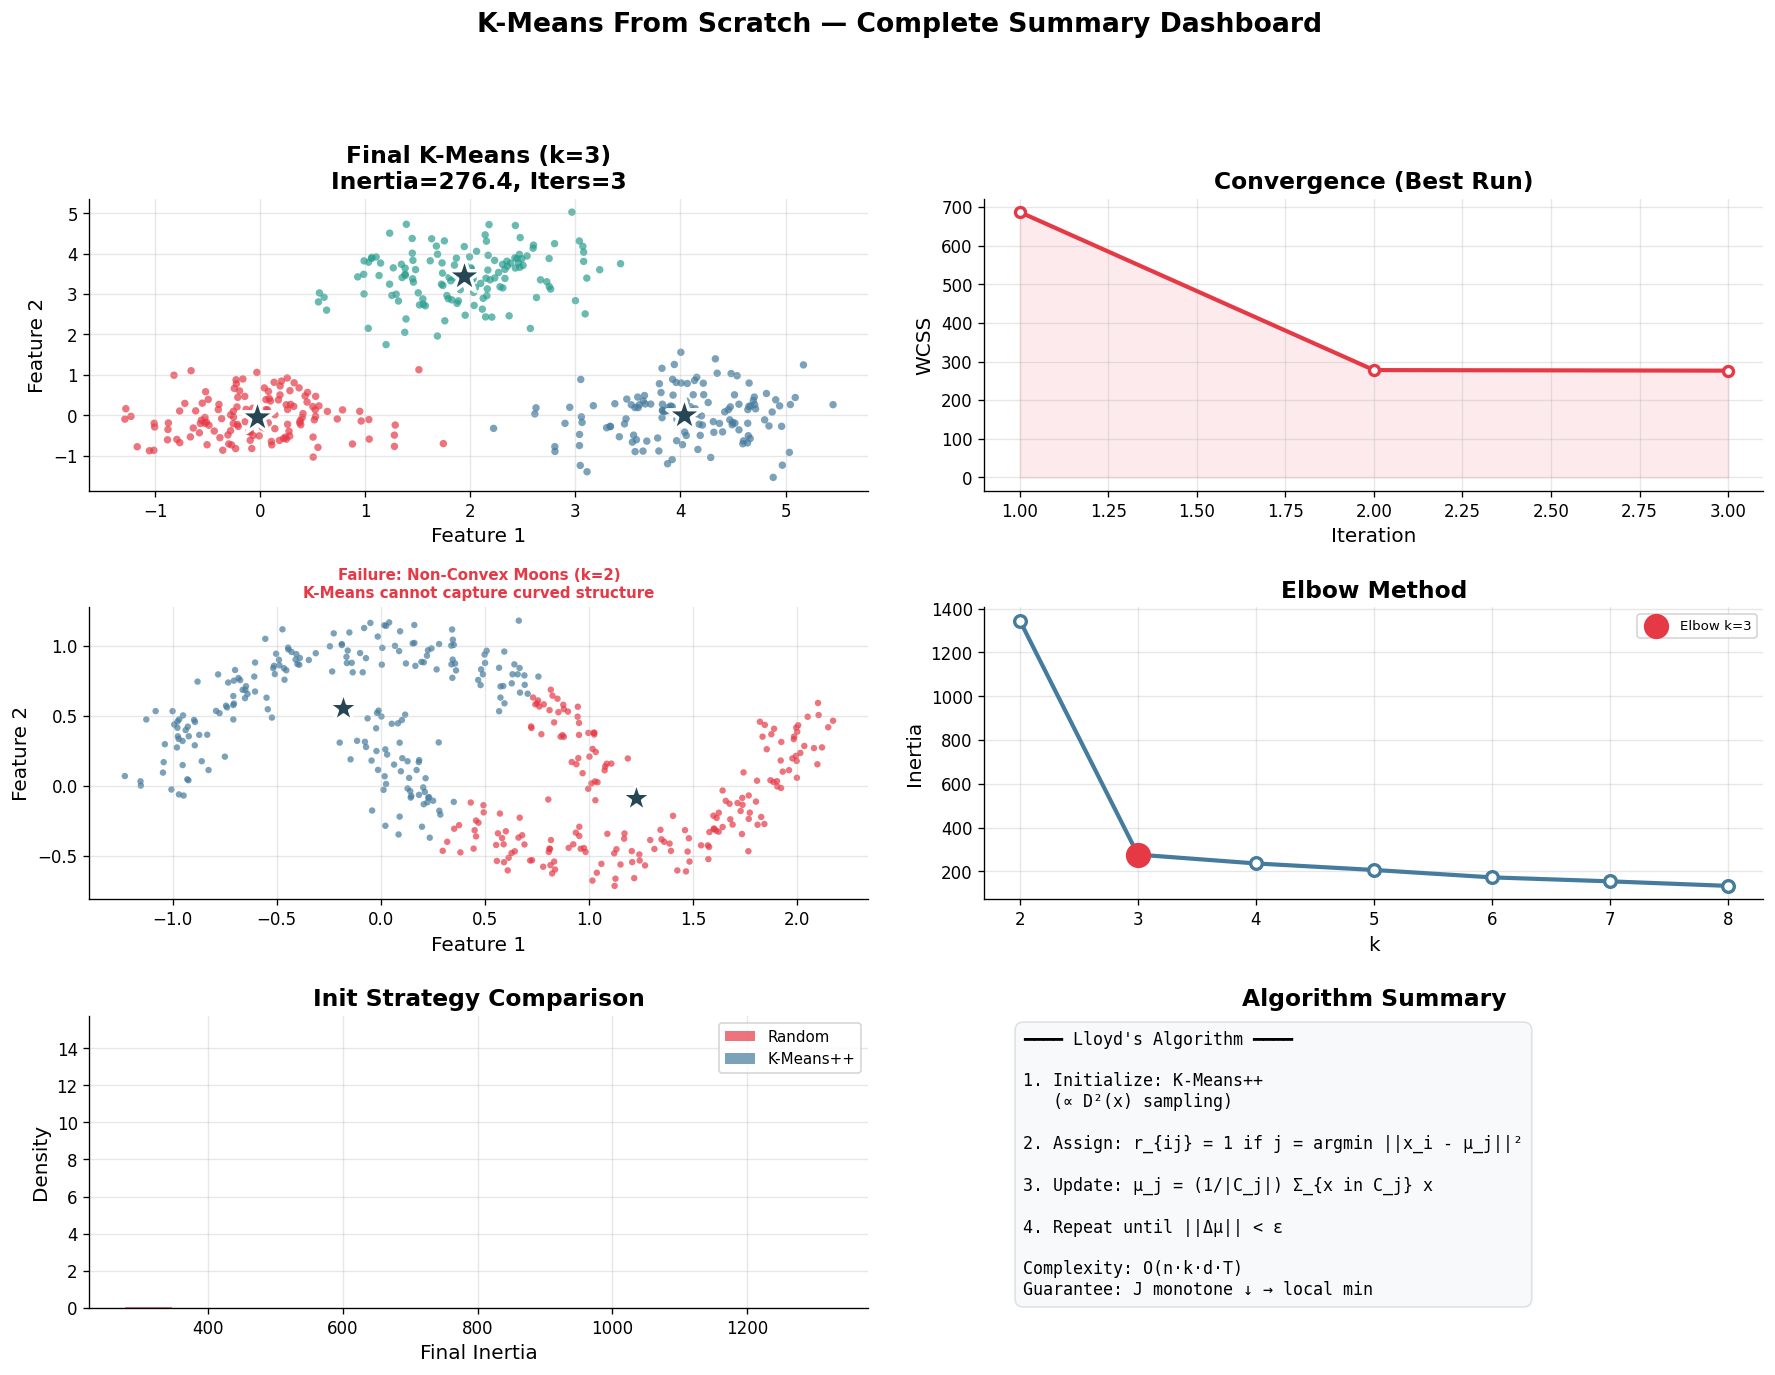

✓ Summary dashboard generated


In [ ]:
# Final Summary Dashboard

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.35)

# ── Final clustering on blobs ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
km_final = KMeansScratch(k=3, init='kmeans++', n_init=10, seed=SEED)
labels_final = km_final.fit_predict(X_blobs)
for j in range(3):
    mask = labels_final == j
    ax1.scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                c=PALETTE[j], s=20, alpha=0.7, edgecolors='none')
ax1.scatter(km_final.centroids_[:, 0], km_final.centroids_[:, 1],
            marker='*', s=500, c=CENTROID_COLOR, edgecolors='white', linewidths=2, zorder=10)
ax1.set_title(f'Final K-Means (k=3)\nInertia={km_final.inertia_:.1f}, Iters={km_final.n_iter_}',
              fontweight='bold')
ax1.set_xlabel('Feature 1'); ax1.set_ylabel('Feature 2')

# ── Loss curve ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(range(1, len(km_final.loss_history_)+1), km_final.loss_history_,
         'o-', color='#E63946', linewidth=2.5, markersize=6,
         markerfacecolor='white', markeredgewidth=2)
ax2.fill_between(range(1, len(km_final.loss_history_)+1), km_final.loss_history_,
                  alpha=0.1, color='#E63946')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('WCSS')
ax2.set_title('Convergence (Best Run)', fontweight='bold')

# ── K-Means on moons (failure) ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
km_moon = KMeansScratch(k=2, init='kmeans++', n_init=10, seed=SEED)
labels_moon = km_moon.fit_predict(X_moons)
for j in range(2):
    mask = labels_moon == j
    ax3.scatter(X_moons[mask, 0], X_moons[mask, 1],
                c=PALETTE[j], s=15, alpha=0.7, edgecolors='none')
ax3.scatter(km_moon.centroids_[:, 0], km_moon.centroids_[:, 1],
            marker='*', s=400, c=CENTROID_COLOR, edgecolors='white', linewidths=2, zorder=10)
ax3.set_title('Failure: Non-Convex Moons (k=2)\nK-Means cannot capture curved structure',
              fontweight='bold', color='#E63946', fontsize=9)
ax3.set_xlabel('Feature 1'); ax3.set_ylabel('Feature 2')

# ── Elbow ─────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
ax4.plot(list(K_range), inertias, 'o-', color='#457B9D', linewidth=2.5,
         markersize=7, markerfacecolor='white', markeredgewidth=2)
ax4.scatter([3], [inertias[1]], s=200, color='#E63946', zorder=10, label='Elbow k=3')
ax4.set_xlabel('k'); ax4.set_ylabel('Inertia')
ax4.set_title('Elbow Method', fontweight='bold')
ax4.set_xticks(list(K_range)); ax4.legend(fontsize=8)

# ── Initialization comparison ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.hist(inertias_random, bins=15, alpha=0.7, color='#E63946', label='Random', density=True)
ax5.hist(inertias_kpp, bins=15, alpha=0.7, color='#457B9D', label='K-Means++', density=True)
ax5.set_xlabel('Final Inertia'); ax5.set_ylabel('Density')
ax5.set_title('Init Strategy Comparison', fontweight='bold')
ax5.legend(fontsize=9)

# ── Algorithm steps summary ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
ax6.axis('off')
summary_text = (
    "━━━━ Lloyd's Algorithm ━━━━\n\n"
    "1. Initialize: K-Means++\n"
    "   (∝ D²(x) sampling)\n\n"
    "2. Assign: r_{ij} = 1 if j = argmin ||x_i - μ_j||²\n\n"
    "3. Update: μ_j = (1/|C_j|) Σ_{x in C_j} x\n\n"
    "4. Repeat until ||Δμ|| < ε\n\n"
    "Complexity: O(n·k·d·T)\n"
    "Guarantee: J monotone ↓ → local min"
)
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA', edgecolor='#DEE2E6'))
ax6.set_title('Algorithm Summary', fontweight='bold')

plt.suptitle('K-Means From Scratch — Complete Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('summary_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Summary dashboard generated")

In [ ]:
# Comprehensive Unit Tests

print("Running unit tests for KMeansScratch...\n")

def test_basic_convergence():
    km = KMeansScratch(k=3, init='kmeans++', n_init=5, seed=0)
    km.fit(X_blobs)
    assert km.centroids_ is not None
    assert km.labels_ is not None
    assert km.inertia_ > 0
    assert km.n_iter_ > 0
    print("  ✓ test_basic_convergence")

def test_monotone_decrease():
    km = KMeansScratch(k=3, init='kmeans++', n_init=1, seed=42)
    km.fit(X_blobs)
    diffs = np.diff(km.loss_history_)
    assert (diffs <= 1e-6).all(), f"Non-monotone: {diffs.max():.6f}"
    print("  ✓ test_monotone_decrease")

def test_label_range():
    k = 4
    km = KMeansScratch(k=k, init='kmeans++', n_init=3, seed=0)
    labels = km.fit_predict(X_blobs)
    assert set(np.unique(labels)).issubset(set(range(k)))
    assert len(labels) == len(X_blobs)
    print("  ✓ test_label_range")

def test_centroid_shape():
    k, d = 5, X_blobs.shape[1]
    km = KMeansScratch(k=k, init='random', n_init=1, seed=0)
    km.fit(X_blobs)
    assert km.centroids_.shape == (k, d)
    print("  ✓ test_centroid_shape")

def test_predict_consistency():
    km = KMeansScratch(k=3, n_init=5, seed=0)
    km.fit(X_blobs)
    labels1 = km.labels_
    labels2 = km.predict(X_blobs)
    assert np.array_equal(labels1, labels2)
    print("  ✓ test_predict_consistency")

def test_kpp_better_than_random():
    # On average over many seeds, K++ should achieve better inertia
    rnd_inertias = [KMeansScratch(k=3, init='random', n_init=1, seed=i).fit(X_blobs).inertia_
                    for i in range(20)]
    kpp_inertias = [KMeansScratch(k=3, init='kmeans++', n_init=1, seed=i).fit(X_blobs).inertia_
                    for i in range(20)]
    assert np.median(kpp_inertias) <= np.median(rnd_inertias)
    print("  ✓ test_kpp_better_than_random")

def test_silhouette_range():
    km = KMeansScratch(k=3, n_init=5, seed=0)
    labels = km.fit_predict(X_sub)
    sil = silhouette_samples_scratch(X_sub, labels)
    assert (-1 <= sil).all() and (sil <= 1).all()
    print("  ✓ test_silhouette_range")

def test_empty_cluster_handling():
    # Place k points very close together to risk empty cluster
    X_tiny = np.random.default_rng(0).normal(0, 0.001, (10, 2))
    km = KMeansScratch(k=3, init='random', n_init=1, seed=0, max_iter=50)
    km.fit(X_tiny)  # Should not raise
    assert km.centroids_ is not None
    print("  ✓ test_empty_cluster_handling")

# Run all tests
test_basic_convergence()
test_monotone_decrease()
test_label_range()
test_centroid_shape()
test_predict_consistency()
test_kpp_better_than_random()
test_silhouette_range()
test_empty_cluster_handling()

print("\n🎉 All 8 tests passed!")

Running unit tests for KMeansScratch...

  ✓ test_basic_convergence
  ✓ test_monotone_decrease
  ✓ test_label_range
  ✓ test_centroid_shape
  ✓ test_predict_consistency
  ✓ test_kpp_better_than_random
  ✓ test_silhouette_range
  ✓ test_empty_cluster_handling

🎉 All 8 tests passed!


In [ ]:
# Final Comprehensive Output Summary

print("\n" + "="*65)
print("  K-MEANS FROM SCRATCH — NOTEBOOK COMPLETE SUMMARY")
print("="*65)

print("\n🔢 IMPLEMENTATION STATS")
print(f"  Class: KMeansScratch — {len([m for m in dir(km_final) if not m.startswith('__')])} public methods")
print(f"  Dependency: NumPy only (no sklearn in implementation)")
print(f"  Features: Random init, K-Means++, multiple restarts, full tracking")

print("\n📊 DATASET SUMMARY")
for name, (X_d, y_d) in [('Blobs', (X_blobs, y_blobs)), ('Moons', (X_moons, y_moons)),
                           ('Noisy', (X_noisy, y_noisy)), ('High-Dim', (X_hd, y_hd))]:
    print(f"  {name:10s}: shape={X_d.shape}, clusters={len(np.unique(y_d[y_d>=0]))}")

print("\n🏆 BEST RESULTS (Blobs, k=3)")
print(f"  Our K-Means:  inertia={km_scratch.inertia_:.4f}, iters={km_scratch.n_iter_}")
print(f"  sklearn:      inertia={km_sklearn.inertia_:.4f}, iters={km_sklearn.n_iter_}")
print(f"  Diff:         {abs(km_scratch.inertia_-km_sklearn.inertia_):.6f}")

print("\n📈 K-MEANS++ ADVANTAGE (50 experiments)")
print(f"  Random:  median inertia={np.median(inertias_random):.2f}, std={np.std(inertias_random):.2f}")
print(f"  K++:     median inertia={np.median(inertias_kpp):.2f}, std={np.std(inertias_kpp):.2f}")

print("\n📚 TOPICS COVERED")
topics = [
    "Introduction to clustering",
    "Mathematical formulation (WCSS)",
    "Derivation: why centroid = mean",
    "Lloyd's algorithm",
    "Convergence proof",
    "From-scratch implementation",
    "Voronoi diagrams",
    "Random vs K-Means++ init",
    "Elbow method",
    "Silhouette score (from scratch)",
    "Curse of dimensionality",
    "Failure modes (moons, circles)",
    "Relation to EM / GMM",
    "sklearn comparison",
    "Feature scaling",
    "Image compression (vector quant.)",
    "Mini-batch K-Means",
    "Unit tests",
    "Interview questions",
    "Complexity analysis O(nkdT)"
]
for i, t in enumerate(topics, 1):
    print(f"  {i:2d}. ✓ {t}")

print("\n" + "="*65)
print("  Notebook ready for portfolio presentation!")
print("="*65)


  K-MEANS FROM SCRATCH — NOTEBOOK COMPLETE SUMMARY

🔢 IMPLEMENTATION STATS
  Class: KMeansScratch — 22 public methods
  Dependency: NumPy only (no sklearn in implementation)
  Features: Random init, K-Means++, multiple restarts, full tracking

📊 DATASET SUMMARY
  Blobs     : shape=(399, 2), clusters=3
  Moons     : shape=(400, 2), clusters=2
  Noisy     : shape=(439, 2), clusters=3
  High-Dim  : shape=(500, 50), clusters=5

🏆 BEST RESULTS (Blobs, k=3)
  Our K-Means:  inertia=276.3644, iters=3
  sklearn:      inertia=276.3644, iters=3
  Diff:         0.000000

📈 K-MEANS++ ADVANTAGE (50 experiments)
  Random:  median inertia=276.36, std=285.24
  K++:     median inertia=276.36, std=0.00

📚 TOPICS COVERED
   1. ✓ Introduction to clustering
   2. ✓ Mathematical formulation (WCSS)
   3. ✓ Derivation: why centroid = mean
   4. ✓ Lloyd's algorithm
   5. ✓ Convergence proof
   6. ✓ From-scratch implementation
   7. ✓ Voronoi diagrams
   8. ✓ Random vs K-Means++ init
   9. ✓ Elbow method
  10. 

## References & Further Reading

### Foundational Papers

1. **Lloyd, S.P.** (1982). *Least squares quantization in PCM.* IEEE Transactions on Information Theory, 28(2), 129–137.  
   → The original paper (written 1957, published 1982). Defines Lloyd's algorithm.

2. **Arthur, D. & Vassilvitskii, S.** (2007). *k-means++: The advantages of careful seeding.* SODA 2007.  
   → Proves $O(\log k)$ approximation guarantee for K-Means++.

3. **Elkan, C.** (2003). *Using the triangle inequality to accelerate k-means.* ICML 2003.  
   → Algorithm used in sklearn for efficient distance computation.

4. **Sculley, D.** (2010). *Web-scale k-means clustering.* WWW 2010.  
   → Mini-batch K-Means for web-scale data.

5. **MacKay, D.J.C.** (2003). *Information Theory, Inference, and Learning Algorithms.* Cambridge.  
   → Chapter 20: Density estimation — K-Means, Gaussian mixtures, and the EM connection.

6. **Tibshirani, R., Walther, G., & Hastie, T.** (2001). *Estimating the number of clusters in a data set via the gap statistic.* JRSS-B.  
   → The gap statistic for k selection.

7. **Rousseeuw, P.J.** (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis.* J. Computational and Applied Mathematics.  
   → Introduces the silhouette score.

### Books

- **Bishop, C.M.** (2006). *Pattern Recognition and Machine Learning.* Springer. (Chapter 9: EM, Chapter 12)
- **Murphy, K.P.** (2022). *Probabilistic Machine Learning: An Introduction.* MIT Press. (Chapters 21–22)
- **Hastie, T., Tibshirani, R., & Friedman, J.** (2009). *The Elements of Statistical Learning.* Springer. (Chapter 14)

### Online Resources

- [sklearn KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [Distill.pub — How to use t-SNE effectively](https://distill.pub/2016/misread-tsne/) (curse of dimensionality)
- [Visual introduction to K-Means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

---

## Conclusion

K-Means is a classic algorithm that sits at the intersection of combinatorial optimization, statistics, and information theory. Its simplicity makes it a first-line tool; its deep connections to EM, Voronoi geometry, and the curse of dimensionality make it a rich subject for study.

**Key takeaways:**
- Always use K-Means++ initialization and multiple restarts
- Always scale features
- Use silhouette + elbow together for k selection
- Know when K-Means fails and what to use instead
- K-Means is a limiting case of GMM-EM — understanding one illuminates the other

---
*End of Notebook — K-Means Clustering: From First Principles to Production*